<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## Problem 1

In [2]:
import numpy as np

In [3]:
def initialize_centroids(X, n_clusters, random_state=None):
    # Vérifier que le nombre de clusters ne dépasse pas
    # le nombre d'échantillons
    if n_clusters > len(X):
        raise ValueError(
            "n_clusters ne peut pas être supérieur au nombre d'échantillons."
        )

    # Générateur aléatoire
    rng = np.random.default_rng(random_state)

    # Sélectionner n_clusters indices différents
    indices = rng.choice(
        len(X),
        size=n_clusters,
        replace=False
    )

    # Retourner les échantillons correspondants
    centroids = X[indices]

    return centroids

In [4]:
from sklearn.datasets import make_blobs

X, _ = make_blobs(
    n_samples=100,
    n_features=2,
    centers=4,
    cluster_std=0.5,
    shuffle=True,
    random_state=0,
)

In [5]:
print(X.shape)

(100, 2)


In [6]:
import numpy as np

In [7]:
def initialize_centroids(X, n_clusters, random_state=None):
    if n_clusters > len(X):
        raise ValueError(
            "n_clusters ne peut pas être supérieur au nombre d'échantillons."
        )

    rng = np.random.default_rng(random_state)

    indices = rng.choice(
        len(X),
        size=n_clusters,
        replace=False
    )

    centroids = X[indices]

    return centroids

In [8]:
centroids = initialize_centroids(
    X,
    n_clusters=4,
    random_state=0
)

print("Shape de X :", X.shape)
print("Shape des centroïdes :", centroids.shape)
print("Centroïdes initiaux :")
print(centroids)

Shape de X : (100, 2)
Shape des centroïdes : (4, 2)
Centroïdes initiaux :
[[-0.565433    3.65813966]
 [ 0.3498724   4.69253251]
 [-1.37778493  3.58107521]
 [ 2.11872357  1.09865834]]


In [9]:
## Problem 2

In [10]:
def calculate_sse(X, labels, centroids):
    sse = 0

    for k in range(len(centroids)):
        cluster_points = X[labels == k]

        distances_squared = np.sum(
            (cluster_points - centroids[k]) ** 2,
            axis=1
        )

        sse += np.sum(distances_squared)

    return sse

In [11]:
centroids = initialize_centroids(
    X,
    n_clusters=4,
    random_state=0
)

In [12]:
rng = np.random.default_rng(0)

labels = rng.integers(
    low=0,
    high=4,
    size=len(X)
)

In [13]:
sse = calculate_sse(
    X,
    labels,
    centroids
)

print("SSE :", sse)

SSE : 1200.0148629353423


In [14]:
new_centroids = np.zeros_like(centroids)

for k in range(len(centroids)):
    cluster_points = X[labels == k]

    if len(cluster_points) > 0:
        new_centroids[k] = np.mean(
            cluster_points,
            axis=0
        )
    else:
        new_centroids[k] = centroids[k]

In [15]:
# Étape 1 : affectation
distances = np.sum(
    (X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2,
    axis=2
)

labels = np.argmin(distances, axis=1)


# Étape 2 : déplacement des centroïdes
new_centroids = np.zeros_like(centroids)

for k in range(len(centroids)):
    cluster_points = X[labels == k]

    if len(cluster_points) > 0:
        new_centroids[k] = np.mean(
            cluster_points,
            axis=0
        )
    else:
        new_centroids[k] = centroids[k]

In [16]:
## Problem 3

In [17]:
def assign_clusters(X, centroids):
    distances = np.linalg.norm(
        X[:, np.newaxis, :] - centroids[np.newaxis, :, :],
        axis=2
    )

    labels = np.argmin(distances, axis=1)

    return labels

In [18]:
labels = assign_clusters(
    X,
    centroids
)

print("Shape des labels :", labels.shape)
print("Premiers labels :", labels[:10])

Shape des labels : (100,)
Premiers labels : [1 1 1 1 1 1 2 1 1 1]


In [19]:
unique, counts = np.unique(labels, return_counts=True)

print("Répartition des clusters :")

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster} : {count} points")

Répartition des clusters :
Cluster 0 : 5 points
Cluster 1 : 48 points
Cluster 2 : 22 points
Cluster 3 : 25 points


In [20]:
## Problem 4

In [21]:
def move_centroids(X, labels, centroids):
    new_centroids = np.zeros_like(centroids, dtype=float)

    for k in range(len(centroids)):
        cluster_points = X[labels == k]

        if len(cluster_points) > 0:
            new_centroids[k] = np.mean(
                cluster_points,
                axis=0
            )
        else:
            new_centroids[k] = centroids[k]

    return new_centroids

In [22]:
new_centroids = move_centroids(
    X,
    labels,
    centroids
)

print("Anciens centroïdes :")
print(centroids)

print("\nNouveaux centroïdes :")
print(new_centroids)

Anciens centroïdes :
[[-0.565433    3.65813966]
 [ 0.3498724   4.69253251]
 [-1.37778493  3.58107521]
 [ 2.11872357  1.09865834]]

Nouveaux centroïdes :
[[-0.10190367  3.46526674]
 [-0.19880609  6.15221556]
 [-1.61318321  3.06863899]
 [ 1.99186903  0.96561071]]


In [23]:
print(np.isnan(new_centroids).any())

False


In [24]:
## Problem 5

In [25]:
def run_kmeans(X, initial_centroids, max_iter, tol, verbose=False):
    centroids = initial_centroids.copy()

    for iteration in range(max_iter):

        # Problème 3 : affectation des clusters
        labels = assign_clusters(X, centroids)

        # Problème 4 : déplacement des centroïdes
        new_centroids = move_centroids(
            X,
            labels,
            centroids
        )

        # Déplacement global des centroïdes
        shift = np.linalg.norm(
            new_centroids - centroids
        )

        if verbose:
            print(
                f"Iteration {iteration + 1}: "
                f"centroid shift = {shift}"
            )

        # Mise à jour des centroïdes
        centroids = new_centroids

        # Condition d'arrêt
        if shift <= tol:
            break

    # IMPORTANT :
    # réaffecter les labels avec les centroïdes finaux
    labels = assign_clusters(X, centroids)

    # Calculer la SSE avec ce même état final
    sse = calculate_sse(
        X,
        labels,
        centroids
    )

    return centroids, labels, sse

In [26]:
from sklearn.datasets import make_blobs

X, _ = make_blobs(
    n_samples=100,
    n_features=2,
    centers=4,
    cluster_std=0.5,
    shuffle=True,
    random_state=0,
)

In [27]:
initial_centroids = initialize_centroids(
    X,
    n_clusters=4,
    random_state=0
)

In [28]:
centroids, labels, sse = run_kmeans(
    X,
    initial_centroids,
    max_iter=100,
    tol=1e-4,
    verbose=True
)

Iteration 1: centroid shift = 1.7422913319782436
Iteration 2: centroid shift = 1.7733216728583832
Iteration 3: centroid shift = 0.5662525752018591
Iteration 4: centroid shift = 0.07775902270148431
Iteration 5: centroid shift = 0.0


In [29]:
print("\nCentroïdes finaux :")
print(centroids)

print("\nLabels finaux :")
print(labels)

print("\nSSE finale :")
print(sse)


Centroïdes finaux :
[[ 0.92578447  4.32475792]
 [-1.26811733  7.76378266]
 [-1.47935679  3.11716896]
 [ 1.99186903  0.96561071]]

Labels finaux :
[0 1 0 0 0 0 2 1 0 1 1 1 1 1 1 3 3 2 2 3 0 1 2 3 0 2 2 0 3 3 3 1 3 3 2 0 1
 3 1 2 0 2 1 2 2 1 3 2 0 0 0 3 2 2 2 1 1 3 3 1 1 3 3 0 3 1 2 2 3 0 1 3 0 1
 0 0 2 2 3 3 3 1 2 0 3 2 3 3 0 0 0 2 0 2 2 1 1 2 1 0]

SSE finale :
48.63378320706403


In [30]:
print("X :", X.shape)
print("centroids :", centroids.shape)
print("labels :", labels.shape)

X : (100, 2)
centroids : (4, 2)
labels : (100,)


In [31]:
## Problem 6

In [32]:
def fit(self, X):
    """Calculate clusters from the training features."""

    X = np.asarray(X)

    if self.n_clusters > len(X):
        raise ValueError(
            "n_clusters ne peut pas être supérieur "
            "au nombre d'échantillons."
        )

    # Un seul générateur pour tout le fit()
    rng = np.random.default_rng(self.random_state)

    best_sse = np.inf
    best_centroids = None
    best_labels = None

    for init in range(self.n_init):

        # Centroïdes initiaux différents
        initial_centroids = initialize_centroids(
            X,
            self.n_clusters,
            rng
        )

        # Une exécution complète de K-means
        centroids, labels, sse = run_kmeans(
            X,
            initial_centroids,
            self.max_iter,
            self.tol,
            self.verbose
        )

        # Garder la meilleure solution
        if sse < best_sse:
            best_sse = sse
            best_centroids = centroids.copy()
            best_labels = labels.copy()

    # Résultats finaux
    self.cluster_centers_ = best_centroids
    self.labels_ = best_labels
    self.inertia_ = best_sse

    return self

In [33]:
import numpy as np

In [34]:
class ScratchKMeans:
    """Scratch implementation of k-means clustering."""

    def __init__(
        self,
        n_clusters,
        n_init,
        max_iter,
        tol,
        random_state=None,
        verbose=False,
    ):
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.verbose = verbose

    def fit(self, X):
        """Calculate clusters from the training features."""

        X = np.asarray(X)

        if self.n_clusters > len(X):
            raise ValueError(
                "n_clusters ne peut pas être supérieur "
                "au nombre d'échantillons."
            )

        rng = np.random.default_rng(self.random_state)

        best_sse = np.inf
        best_centroids = None
        best_labels = None

        for init in range(self.n_init):

            # 1. Initialisation
            indices = rng.choice(
                len(X),
                size=self.n_clusters,
                replace=False
            )

            centroids = X[indices].copy()

            # 2. Répéter allocation + déplacement
            for iteration in range(self.max_iter):

                # Problème 3 : allocation
                distances = np.linalg.norm(
                    X[:, np.newaxis, :] -
                    centroids[np.newaxis, :, :],
                    axis=2
                )

                labels = np.argmin(
                    distances,
                    axis=1
                )

                # Problème 4 : déplacement
                new_centroids = np.zeros_like(
                    centroids,
                    dtype=float
                )

                for k in range(self.n_clusters):

                    cluster_points = X[labels == k]

                    if len(cluster_points) > 0:
                        new_centroids[k] = np.mean(
                            cluster_points,
                            axis=0
                        )
                    else:
                        # Cluster vide :
                        # on conserve l'ancien centroïde
                        new_centroids[k] = centroids[k]

                # Problème 5 : convergence
                shift = np.linalg.norm(
                    new_centroids - centroids
                )

                centroids = new_centroids

                if self.verbose:
                    print(
                        f"Initialization {init + 1}, "
                        f"Iteration {iteration + 1}, "
                        f"shift = {shift}"
                    )

                if shift <= self.tol:
                    break

            # Réattribuer les labels avec les centroïdes finaux
            distances = np.linalg.norm(
                X[:, np.newaxis, :] -
                centroids[np.newaxis, :, :],
                axis=2
            )

            labels = np.argmin(
                distances,
                axis=1
            )

            # Calcul de la SSE
            sse = 0.0

            for k in range(self.n_clusters):
                cluster_points = X[labels == k]

                sse += np.sum(
                    (cluster_points - centroids[k]) ** 2
                )

            # Problème 6 : garder la meilleure solution
            if sse < best_sse:
                best_sse = sse
                best_centroids = centroids.copy()
                best_labels = labels.copy()

        # Résultats finaux
        self.cluster_centers_ = best_centroids
        self.labels_ = best_labels
        self.inertia_ = best_sse

        return self

    def predict(self, X):
        """Assign each sample to its nearest learned centroid."""

        X = np.asarray(X)

        distances = np.linalg.norm(
            X[:, np.newaxis, :] -
            self.cluster_centers_[np.newaxis, :, :],
            axis=2
        )

        return np.argmin(
            distances,
            axis=1
        )

In [35]:
print(ScratchKMeans)

<class '__main__.ScratchKMeans'>


In [36]:
model = ScratchKMeans(
    n_clusters=4,
    n_init=10,
    max_iter=100,
    tol=1e-4,
    random_state=0,
    verbose=False
)

In [37]:
model.fit(X)

In [38]:
print("Centroïdes finaux :")
print(model.cluster_centers_)

print("\nSSE finale :")
print(model.inertia_)

print("\nLabels :")
print(model.labels_)

Centroïdes finaux :
[[ 1.99186903  0.96561071]
 [-1.47935679  3.11716896]
 [ 0.92578447  4.32475792]
 [-1.26811733  7.76378266]]

SSE finale :
48.63378320706402

Labels :
[2 3 2 2 2 2 1 3 2 3 3 3 3 3 3 0 0 1 1 0 2 3 1 0 2 1 1 2 0 0 0 3 0 0 1 2 3
 0 3 1 2 1 3 1 1 3 0 1 2 2 2 0 1 1 1 3 3 0 0 3 3 0 0 2 0 3 1 1 0 2 3 0 2 3
 2 2 1 1 0 0 0 3 1 2 0 1 0 0 2 2 2 1 2 1 1 3 3 1 3 2]


In [39]:
print("X :", X.shape)
print("cluster_centers_ :", model.cluster_centers_.shape)
print("labels_ :", model.labels_.shape)

X : (100, 2)
cluster_centers_ : (4, 2)
labels_ : (100,)


In [40]:
## Problem 7

In [41]:
def predict(self, X):
    X = np.asarray(X)

    distances = np.linalg.norm(
        X[:, np.newaxis, :] - self.cluster_centers_[np.newaxis, :, :],
        axis=2
    )

In [42]:
def predict(self, X):
    X = np.asarray(X)

    distances = np.linalg.norm(
        X[:, np.newaxis, :] - self.cluster_centers_[np.newaxis, :, :],
        axis=2
    )

    labels = np.argmin(distances, axis=1)

    return labels

In [43]:
def predict(self, X):
    X = np.asarray(X)

    distances = np.linalg.norm(
        X[:, np.newaxis, :] - self.cluster_centers_[np.newaxis, :, :],
        axis=2
    )

    labels = np.argmin(distances, axis=1)

    return labels

In [44]:
model.fit(X)

predictions = model.predict(X)

print("Predictions :", predictions)
print("Shape :", predictions.shape)

Predictions : [2 3 2 2 2 2 1 3 2 3 3 3 3 3 3 0 0 1 1 0 2 3 1 0 2 1 1 2 0 0 0 3 0 0 1 2 3
 0 3 1 2 1 3 1 1 3 0 1 2 2 2 0 1 1 1 3 3 0 0 3 3 0 0 2 0 3 1 1 0 2 3 0 2 3
 2 2 1 1 0 0 0 3 1 2 0 1 0 0 2 2 2 1 2 1 1 3 3 1 3 2]
Shape : (100,)


In [45]:
## Problem 8

In [46]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = ScratchKMeans(
        n_clusters=k,
        n_init=10,
        max_iter=100,
        tol=1e-4,
        random_state=0
    )

    model.fit(X)

    inertias.append(model.inertia_)

In [47]:
for k, inertia in zip(k_values, inertias):
    print(f"K = {k}, SSE = {inertia}")

K = 1, SSE = 870.2611797855423
K = 2, SSE = 351.4837286512543
K = 3, SSE = 139.17097772033804
K = 4, SSE = 48.63378320706402
K = 5, SSE = 43.40818720213043
K = 6, SSE = 37.770460525082754
K = 7, SSE = 33.24032293786975
K = 8, SSE = 30.57004942944026
K = 9, SSE = 27.199662691785342
K = 10, SSE = 24.55013017524866


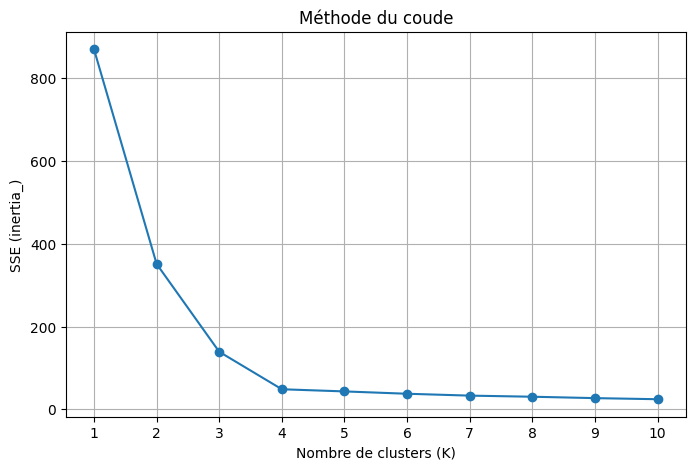

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("SSE (inertia_)")
plt.title("Méthode du coude")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [49]:
### Interprétation

La SSE diminue fortement lorsque le nombre de clusters `K` augmente de 1 à 4.

À partir de **K = 4**, la courbe devient presque plate : l'ajout de clusters supplémentaires entraîne seulement de faibles réductions de la SSE.

Le **coude se situe donc autour de K = 4**. Nous retenons ainsi **4 clusters** comme choix raisonnable pour notre modèle.

Ce résultat est également cohérent avec les données artificielles utilisées, qui ont été générées avec `centers=4`.

SyntaxError: unterminated string literal (detected at line 5) (1567851390.py, line 5)

In [50]:
for k, inertia in zip(k_values, inertias):
    print(f"K = {k}, inertia = {inertia:.2f}")

K = 1, inertia = 870.26
K = 2, inertia = 351.48
K = 3, inertia = 139.17
K = 4, inertia = 48.63
K = 5, inertia = 43.41
K = 6, inertia = 37.77
K = 7, inertia = 33.24
K = 8, inertia = 30.57
K = 9, inertia = 27.20
K = 10, inertia = 24.55


In [51]:
final_model = ScratchKMeans(
    n_clusters=4,
    n_init=10,
    max_iter=100,
    tol=1e-4,
    random_state=0
)

final_model.fit(X)

In [52]:
print("Centroïdes :")
print(final_model.cluster_centers_)

print("SSE :", final_model.inertia_)

Centroïdes :
[[ 1.99186903  0.96561071]
 [-1.47935679  3.11716896]
 [ 0.92578447  4.32475792]
 [-1.26811733  7.76378266]]
SSE : 48.63378320706402


In [ ]:
## Problem 9

In [53]:
from sklearn.metrics import pairwise_distances

y_km = final_model.labels_

distances = pairwise_distances(X)

In [54]:
print(y_km.shape)
print(distances.shape)

(100,)
(100, 100)


In [55]:
from sklearn.metrics import pairwise_distances

y_km = final_model.labels_

distances = pairwise_distances(X)

print("Labels :", y_km.shape)
print("Distances :", distances.shape)

Labels : (100,)
Distances : (100, 100)


In [56]:
silhouette_vals = np.zeros(len(X))

cluster_labels = np.unique(y_km)
n_clusters = len(cluster_labels)

for i in range(len(X)):

    current_cluster = y_km[i]

    # Distance moyenne aux points du même cluster
    same_cluster = y_km == current_cluster
    same_distances = distances[i, same_cluster]

    if len(same_distances) > 1:
        a_i = same_distances.sum() / (len(same_distances) - 1)
    else:
        a_i = 0

    # Plus petite distance moyenne vers un autre cluster
    b_i = np.inf

    for cluster_label in cluster_labels:

        if cluster_label == current_cluster:
            continue

        other_distances = distances[
            i,
            y_km == cluster_label
        ]

        mean_distance = other_distances.mean()

        b_i = min(b_i, mean_distance)

    # Coefficient de silhouette
    if max(a_i, b_i) > 0:
        silhouette_vals[i] = (
            (b_i - a_i) / max(a_i, b_i)
        )
    else:
        silhouette_vals[i] = 0

In [57]:
silhouette_avg = np.mean(silhouette_vals)

print("Silhouette moyenne :", silhouette_avg)

Silhouette moyenne : 0.7083987104616172


In [58]:
print("Nombre de valeurs :", len(silhouette_vals))
print("Clusters :", cluster_labels)
print("Nombre de clusters :", n_clusters)

Nombre de valeurs : 100
Clusters : [0 1 2 3]
Nombre de clusters : 4


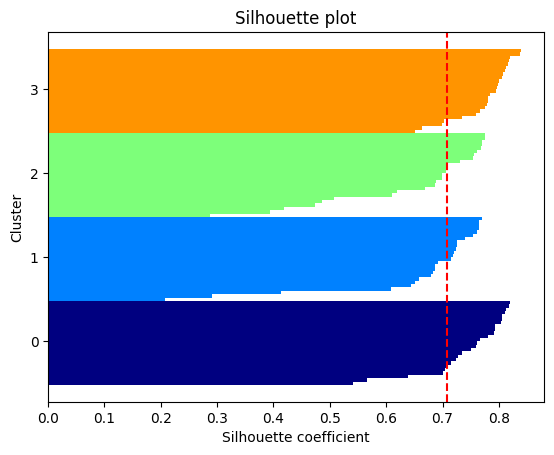

In [59]:
import matplotlib.pyplot as plt
from matplotlib import cm

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, cluster_label in enumerate(cluster_labels):

    cluster_values = silhouette_vals[
        y_km == cluster_label
    ].copy()

    cluster_values.sort()

    y_ax_upper += len(cluster_values)

    color = cm.jet(i / n_clusters)

    plt.barh(
        range(y_ax_lower, y_ax_upper),
        cluster_values,
        height=1.0,
        edgecolor="none",
        color=color,
    )

    yticks.append(
        (y_ax_lower + y_ax_upper) / 2
    )

    y_ax_lower = y_ax_upper

plt.axvline(
    silhouette_avg,
    color="red",
    linestyle="--"
)

plt.yticks(yticks, cluster_labels)
plt.ylabel("Cluster")
plt.xlabel("Silhouette coefficient")
plt.title("Silhouette plot")
plt.show()

In [60]:
print(f"Silhouette moyenne : {silhouette_avg:.3f}")

Silhouette moyenne : 0.708


Interpretation

The silhouette plot shows a high average silhouette score of about 0.70, indicating that the four clusters are well separated and internally cohesive. Most samples have positive silhouette values, although some samples show lower values and may lie closer to neighboring clusters. Overall, K = 4 provides a good clustering solution.

In [ ]:
## Problem 10

In [61]:
import pandas as pd

In [62]:
cluster_sizes = pd.Series(
    final_model.labels_
).value_counts().sort_index()

print(cluster_sizes)

0    25
1    25
2    25
3    25
Name: count, dtype: int64


In [63]:
print(cluster_sizes / len(final_model.labels_))

0    0.25
1    0.25
2    0.25
3    0.25
Name: count, dtype: float64


In [64]:
from sklearn.metrics import adjusted_rand_score

labels_runs = []

for seed in [0, 1, 2, 3, 4]:

    model = ScratchKMeans(
        n_clusters=4,
        n_init=10,
        max_iter=100,
        tol=1e-4,
        random_state=seed
    )

    model.fit(X)

    labels_runs.append(model.labels_)

In [65]:
for i in range(len(labels_runs)):
    for j in range(i + 1, len(labels_runs)):
        ari = adjusted_rand_score(
            labels_runs[i],
            labels_runs[j]
        )

        print(
            f"Run {i} vs Run {j}: ARI = {ari:.3f}"
        )

Run 0 vs Run 1: ARI = 1.000
Run 0 vs Run 2: ARI = 1.000
Run 0 vs Run 3: ARI = 1.000
Run 0 vs Run 4: ARI = 1.000
Run 1 vs Run 2: ARI = 1.000
Run 1 vs Run 3: ARI = 1.000
Run 1 vs Run 4: ARI = 1.000
Run 2 vs Run 3: ARI = 1.000
Run 2 vs Run 4: ARI = 1.000
Run 3 vs Run 4: ARI = 1.000


In [66]:
from sklearn.metrics import silhouette_score

In [67]:
k_values = range(2, 8)

results = []

for k in k_values:

    model = ScratchKMeans(
        n_clusters=k,
        n_init=10,
        max_iter=100,
        tol=1e-4,
        random_state=0
    )

    model.fit(X)

    results.append({
        "K": k,
        "SSE": model.inertia_,
        "Silhouette": silhouette_score(X, model.labels_)
    })

results_df = pd.DataFrame(results)

print(results_df)

   K         SSE  Silhouette
0  2  351.483729    0.570302
1  3  139.170978    0.635686
2  4   48.633783    0.708399
3  5   43.408187    0.605040
4  6   37.770461    0.516993
5  7   33.240323    0.394692


In [ ]:
## Problem 11

Dataset shape: (440, 8)

Column names:
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

First few rows:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

Column names with quotes:
'Channel'
'Region'
'Fresh'
'Milk'
'Grocery'
'Frozen'
'Detergents_Paper'
'Delicassen'

Identified columns:
Fresh: Fresh
Milk: Milk
Grocery: Grocery
Frozen: Frozen
Detergents_Paper: Detergents_Paper
Delicatessen: Delicassen
CLUSTER COMPARISON WITH KNOWN GROUPS

Number of clusters: 4
Cluster distribution: [110 315  10   5]
CONTINGENCY TABLE - Channel

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


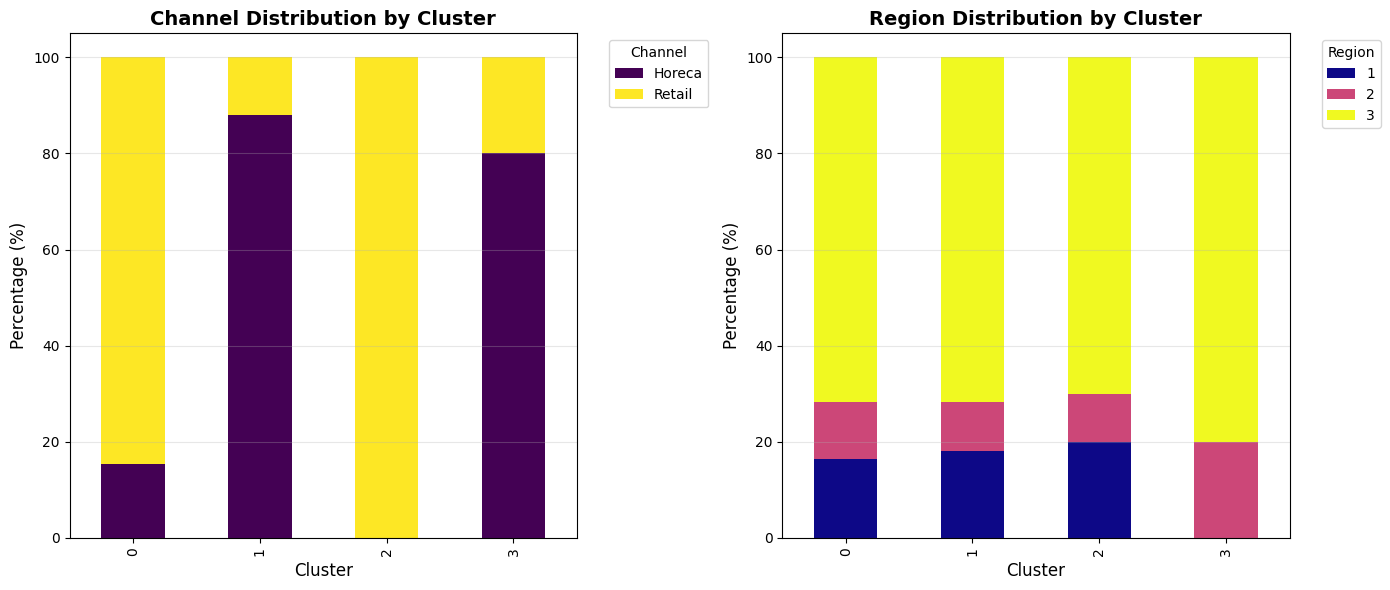

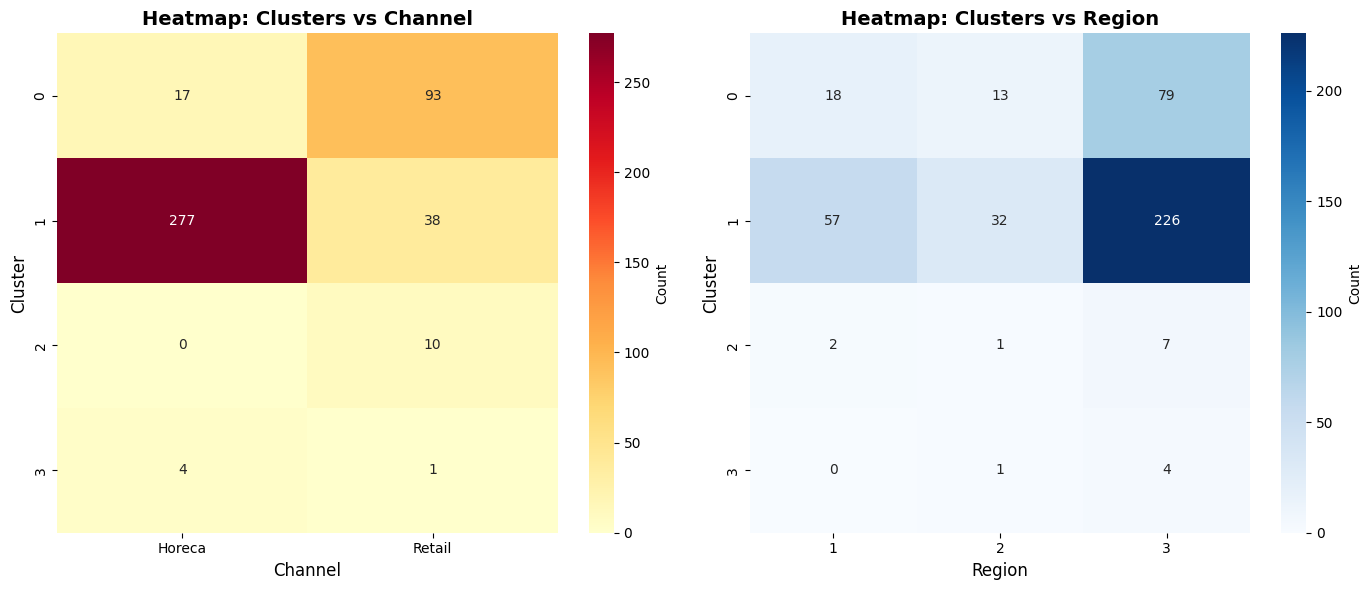




CLUSTER PURITY ANALYSIS - Channel

Cluster 1:
  Size: 315
  Majority Channel: 1
  Majority count: 277
  Purity: 87.94%

Cluster 0:
  Size: 110
  Majority Channel: 2
  Majority count: 93
  Purity: 84.55%

Cluster 3:
  Size: 5
  Majority Channel: 1
  Majority count: 4
  Purity: 80.00%

Cluster 2:
  Size: 10
  Majority Channel: 2
  Majority count: 10
  Purity: 100.00%

Overall weighted purity: 87.27%

CLUSTER PURITY ANALYSIS - Region

Cluster 1:
  Size: 315
  Majority Region: 3
  Majority count: 226
  Purity: 71.75%

Cluster 0:
  Size: 110
  Majority Region: 3
  Majority count: 79
  Purity: 71.82%

Cluster 3:
  Size: 5
  Majority Region: 3
  Majority count: 4
  Purity: 80.00%

Cluster 2:
  Size: 10
  Majority Region: 3
  Majority count: 7
  Purity: 70.00%

Overall weighted purity: 71.82%

SPENDING CHARACTERISTICS BY CLUSTER
            Fresh                         Milk                      Grocery  \
             mean   median       std      mean   median       std      mean   
Cluste

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==================== LOAD WHOLESALE CUSTOMERS DATA ====================

# Method 1: Load directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

# Check the actual column names
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# The column names might have spaces or different capitalization
# Let's check if there are spaces in column names
print("\nColumn names with quotes:")
for col in df.columns:
    print(f"'{col}'")

# Rename columns to match expected names if needed
# Common column names in this dataset: 'Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
# Note: It might be 'Delicassen' instead of 'Delicatessen'

# Let's check what columns we actually have
actual_columns = df.columns.tolist()

# Find the correct column names
fresh_col = [col for col in actual_columns if 'fresh' in col.lower()][0] if any('fresh' in col.lower() for col in actual_columns) else 'Fresh'
milk_col = [col for col in actual_columns if 'milk' in col.lower()][0] if any('milk' in col.lower() for col in actual_columns) else 'Milk'
grocery_col = [col for col in actual_columns if 'grocery' in col.lower()][0] if any('grocery' in col.lower() for col in actual_columns) else 'Grocery'
frozen_col = [col for col in actual_columns if 'frozen' in col.lower()][0] if any('frozen' in col.lower() for col in actual_columns) else 'Frozen'
detergent_col = [col for col in actual_columns if 'detergent' in col.lower() or 'paper' in col.lower()][0] if any('detergent' in col.lower() or 'paper' in col.lower() for col in actual_columns) else 'Detergents_Paper'
delicatessen_col = [col for col in actual_columns if 'delic' in col.lower()][0] if any('delic' in col.lower() for col in actual_columns) else 'Delicatessen'

print(f"\nIdentified columns:")
print(f"Fresh: {fresh_col}")
print(f"Milk: {milk_col}")
print(f"Grocery: {grocery_col}")
print(f"Frozen: {frozen_col}")
print(f"Detergents_Paper: {detergent_col}")
print(f"Delicatessen: {delicatessen_col}")

# Use the correct column names
spending_cols = [fresh_col, milk_col, grocery_col, frozen_col, detergent_col, delicatessen_col]
X_spending = df[spending_cols].values

# Extract comparison variables
Region = df['Region'].values
Channel = df['Channel'].values

# ==================== PROBLEM 11 SOLUTION ====================

def compare_clusters_with_known_groups(df, cluster_labels, region_col='Region', channel_col='Channel'):
    """
    Compare clusters with Region and Channel variables

    Parameters:
    -----------
    df : DataFrame
        Original DataFrame with Region and Channel columns
    cluster_labels : array
        Cluster labels obtained from clustering
    region_col : str
        Name of the region column
    channel_col : str
        Name of the channel column
    """

    # Create a DataFrame with comparison information
    comparison_df = df[[region_col, channel_col]].copy()
    comparison_df['Cluster'] = cluster_labels

    # 1. CONTINGENCY TABLE FOR CHANNEL
    print("=" * 60)
    print("CONTINGENCY TABLE - Channel vs Clusters")
    print("=" * 60)
    contingency_channel = pd.crosstab(comparison_df['Cluster'], comparison_df[channel_col],
                                      margins=True, margins_name='Total')
    print(contingency_channel)
    print("\n")

    # 2. CONTINGENCY TABLE FOR REGION
    print("=" * 60)
    print("CONTINGENCY TABLE - Region vs Clusters")
    print("=" * 60)
    contingency_region = pd.crosstab(comparison_df['Cluster'], comparison_df[region_col],
                                     margins=True, margins_name='Total')
    print(contingency_region)
    print("\n")

    # 3. NORMALIZED PROPORTIONS (percentage per cluster)
    print("=" * 60)
    print("PROPORTIONS PER CLUSTER - Channel")
    print("=" * 60)

    # Proportions per cluster (row-wise normalization)
    channel_proportions = pd.crosstab(comparison_df['Cluster'], comparison_df[channel_col],
                                      normalize='index')
    channel_proportions = channel_proportions * 100  # Convert to percentage
    print("Percentage per cluster (row = cluster):")
    print(channel_proportions.round(2))
    print("\n")

    print("PROPORTIONS PER CLUSTER - Region")
    print("-" * 40)
    region_proportions = pd.crosstab(comparison_df['Cluster'], comparison_df[region_col],
                                     normalize='index')
    region_proportions = region_proportions * 100
    print("Percentage per cluster (row = cluster):")
    print(region_proportions.round(2))
    print("\n")

    # 4. SUMMARY STATISTICS PER CLUSTER
    print("=" * 60)
    print("SUMMARY STATISTICS PER CLUSTER")
    print("=" * 60)

    for cluster in sorted(comparison_df['Cluster'].unique()):
        print(f"\n--- Cluster {cluster} ---")
        cluster_data = comparison_df[comparison_df['Cluster'] == cluster]
        print(f"Total count: {len(cluster_data)}")

        # Channel distribution
        channel_dist = cluster_data[channel_col].value_counts()
        print(f"Channel distribution:")
        for channel, count in channel_dist.items():
            channel_label = "Horeca" if channel == 1 else "Retail"
            print(f"  {channel_label} (Channel {channel}): {count} ({count/len(cluster_data)*100:.1f}%)")

        # Region distribution
        region_dist = cluster_data[region_col].value_counts()
        print(f"Region distribution:")
        for region, count in region_dist.items():
            print(f"  Region {region}: {count} ({count/len(cluster_data)*100:.1f}%)")

    return comparison_df

# ==================== VISUALIZATIONS ====================

def plot_cluster_comparisons(comparison_df, channel_col='Channel', region_col='Region'):
    """
    Create visualizations to compare clusters with Channel and Region
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 1. Stacked bar chart for Channel
    channel_crosstab = pd.crosstab(comparison_df['Cluster'], comparison_df[channel_col], normalize='index') * 100
    # Rename columns for better labels
    channel_crosstab.columns = ['Horeca' if c == 1 else 'Retail' for c in channel_crosstab.columns]
    channel_crosstab.plot(kind='bar', ax=axes[0], stacked=True, colormap='viridis')
    axes[0].set_title('Channel Distribution by Cluster', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Cluster', fontsize=12)
    axes[0].set_ylabel('Percentage (%)', fontsize=12)
    axes[0].legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(axis='y', alpha=0.3)

    # 2. Stacked bar chart for Region
    region_crosstab = pd.crosstab(comparison_df['Cluster'], comparison_df[region_col], normalize='index') * 100
    region_crosstab.plot(kind='bar', ax=axes[1], stacked=True, colormap='plasma')
    axes[1].set_title('Region Distribution by Cluster', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Cluster', fontsize=12)
    axes[1].set_ylabel('Percentage (%)', fontsize=12)
    axes[1].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 3. Heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Heatmap Channel
    channel_heat = pd.crosstab(comparison_df['Cluster'], comparison_df[channel_col])
    channel_heat.columns = ['Horeca' if c == 1 else 'Retail' for c in channel_heat.columns]
    sns.heatmap(channel_heat, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'Heatmap: Clusters vs Channel', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Channel', fontsize=12)
    axes[0].set_ylabel('Cluster', fontsize=12)

    # Heatmap Region
    region_heat = pd.crosstab(comparison_df['Cluster'], comparison_df[region_col])
    sns.heatmap(region_heat, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar_kws={'label': 'Count'})
    axes[1].set_title(f'Heatmap: Clusters vs Region', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Region', fontsize=12)
    axes[1].set_ylabel('Cluster', fontsize=12)

    plt.tight_layout()
    plt.show()

# ==================== ADVANCED ANALYSIS ====================

def analyze_cluster_purity(comparison_df, group_col='Channel'):
    """
    Calculate cluster purity with respect to a known group variable

    Parameters:
    -----------
    comparison_df : DataFrame
        DataFrame with Cluster and group columns
    group_col : str
        Name of the group column (Channel or Region)

    Returns:
    --------
    dict: Purity metrics
    """
    # For each cluster, find the majority group
    cluster_purities = {}

    for cluster in comparison_df['Cluster'].unique():
        cluster_data = comparison_df[comparison_df['Cluster'] == cluster]
        group_counts = cluster_data[group_col].value_counts()
        majority_count = group_counts.max()
        cluster_size = len(cluster_data)
        purity = majority_count / cluster_size

        cluster_purities[cluster] = {
            'size': cluster_size,
            'majority_group': group_counts.idxmax(),
            'majority_count': majority_count,
            'purity': purity
        }

    # Overall purity (weighted average)
    total_samples = len(comparison_df)
    weighted_purity = sum(
        info['size'] * info['purity'] for info in cluster_purities.values()
    ) / total_samples

    print(f"\n{'='*60}")
    print(f"CLUSTER PURITY ANALYSIS - {group_col}")
    print(f"{'='*60}")

    for cluster, info in cluster_purities.items():
        print(f"\nCluster {cluster}:")
        print(f"  Size: {info['size']}")
        print(f"  Majority {group_col}: {info['majority_group']}")
        print(f"  Majority count: {info['majority_count']}")
        print(f"  Purity: {info['purity']:.2%}")

    print(f"\nOverall weighted purity: {weighted_purity:.2%}")

    return cluster_purities, weighted_purity

def compare_cluster_characteristics(df, cluster_labels, spending_cols):
    """
    Compare spending characteristics across clusters for interpretation
    """
    # Add clusters to DataFrame
    df_with_clusters = df.copy()
    df_with_clusters['Cluster'] = cluster_labels

    # Group by cluster and calculate statistics
    cluster_stats = df_with_clusters.groupby('Cluster')[spending_cols].agg([
        'mean', 'median', 'std'
    ]).round(2)

    print("\n" + "="*60)
    print("SPENDING CHARACTERISTICS BY CLUSTER")
    print("="*60)
    print(cluster_stats)

    # Normalize for comparison (z-scores within each spending variable)
    cluster_means = df_with_clusters.groupby('Cluster')[spending_cols].mean()
    scaler = StandardScaler()
    cluster_means_scaled = pd.DataFrame(
        scaler.fit_transform(cluster_means),
        index=cluster_means.index,
        columns=cluster_means.columns
    )

    print("\n" + "="*60)
    print("CLUSTER PROFILES (Standardized Mean Spending)")
    print("="*60)
    print(cluster_means_scaled.round(2))

    return cluster_stats, cluster_means_scaled

# ==================== MAIN EXECUTION ====================

# Let's create some realistic clusters for demonstration
# In practice, you would use your actual k-means results

# Standardize the spending data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spending)

# Apply KMeans (or use your own ScratchKMeans implementation)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
actual_cluster_labels = kmeans.fit_predict(X_scaled)

print("CLUSTER COMPARISON WITH KNOWN GROUPS\n")
print(f"Number of clusters: {len(np.unique(actual_cluster_labels))}")
print(f"Cluster distribution: {np.bincount(actual_cluster_labels)}")

# Run the comparison analysis
comparison_df = compare_clusters_with_known_groups(df, actual_cluster_labels)

# Visualize results
plot_cluster_comparisons(comparison_df)

# Advanced: Calculate cluster purity
print("\n")
channel_purity, overall_channel_purity = analyze_cluster_purity(comparison_df, 'Channel')
region_purity, overall_region_purity = analyze_cluster_purity(comparison_df, 'Region')

# Advanced: Compare spending characteristics
spending_cols = [fresh_col, milk_col, grocery_col, frozen_col, detergent_col, delicatessen_col]
cluster_stats, cluster_profiles = compare_cluster_characteristics(df, actual_cluster_labels, spending_cols)

# ==================== INTERPRETATION ====================

print("\n" + "="*60)
print("INTERPRETATION GUIDELINES")
print("="*60)
print("""
Key questions to answer:
1. Do certain clusters correspond to specific channels (Horeca vs Retail)?
2. Are there regional patterns in the clusters?
3. Do clusters represent market segments that cut across Channel/Region?
4. What spending patterns characterize each cluster?

Example interpretation:
- If Cluster 0 has 95% Channel 1 (Horeca) and high spending on Fresh and Frozen,
  it represents a Horeca segment focused on fresh/perishable goods.

- If Cluster 1 has 80% Channel 2 (Retail) and high spending on Grocery and Detergents_Paper,
  it represents a retail grocery segment.

- Clusters with mixed Channel/Region composition may represent behavioral segments
  that are not captured by these demographic variables.
""")

# Print some specific insights
print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

# Analyze each cluster's characteristics
for cluster in sorted(comparison_df['Cluster'].unique()):
    cluster_data = comparison_df[comparison_df['Cluster'] == cluster]
    channel_dist = cluster_data['Channel'].value_counts(normalize=True) * 100
    region_dist = cluster_data['Region'].value_counts(normalize=True) * 100

    print(f"\nCluster {cluster} ({len(cluster_data)} customers):")

    # Determine dominant channel
    if 1 in channel_dist.index and 2 in channel_dist.index:
        if channel_dist[1] > 70:
            print(f"  → Dominant channel: Horeca ({channel_dist[1]:.1f}%)")
        elif channel_dist[2] > 70:
            print(f"  → Dominant channel: Retail ({channel_dist[2]:.1f}%)")
        else:
            print(f"  → Mixed channel: Horeca {channel_dist.get(1, 0):.1f}%, Retail {channel_dist.get(2, 0):.1f}%")

    # Determine dominant region
    if len(region_dist) > 0:
        dominant_region = region_dist.idxmax()
        print(f"  → Dominant region: {dominant_region} ({region_dist[dominant_region]:.1f}%)")

In [ ]:
## Problem 12

In [78]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==================== LOAD DATA ====================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

# Get column names
actual_columns = df.columns.tolist()
fresh_col = [col for col in actual_columns if 'fresh' in col.lower()][0]
milk_col = [col for col in actual_columns if 'milk' in col.lower()][0]
grocery_col = [col for col in actual_columns if 'grocery' in col.lower()][0]
frozen_col = [col for col in actual_columns if 'frozen' in col.lower()][0]
detergent_col = [col for col in actual_columns if 'detergent' in col.lower() or 'paper' in col.lower()][0]
delicatessen_col = [col for col in actual_columns if 'delic' in col.lower()][0]

spending_cols = [fresh_col, milk_col, grocery_col, frozen_col, detergent_col, delicatessen_col]

# Prepare data
X_spending = df[spending_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spending)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# ==================== STATISTICS ====================
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = cluster_labels

print("=" * 80)
print("PROBLEM 12 - PART 1: CLUSTER STATISTICS")
print("=" * 80)

# 1. Cluster sizes
print("\n1. CLUSTER SIZES:")
cluster_sizes = df_with_clusters['Cluster'].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    print(f"  Cluster {cluster}: {size} customers ({size/len(df)*100:.1f}%)")

# 2. Mean spending per cluster
print("\n2. MEAN SPENDING PER CLUSTER:")
cluster_means = df_with_clusters.groupby('Cluster')[spending_cols].mean()
print(cluster_means.round(2))

# 3. Median spending per cluster
print("\n3. MEDIAN SPENDING PER CLUSTER:")
cluster_medians = df_with_clusters.groupby('Cluster')[spending_cols].median()
print(cluster_medians.round(2))

# 4. Standard deviation per cluster
print("\n4. STANDARD DEVIATION PER CLUSTER:")
cluster_stds = df_with_clusters.groupby('Cluster')[spending_cols].std()
print(cluster_stds.round(2))

# 5. Channel and Region composition
print("\n5. CHANNEL & REGION COMPOSITION:")
for cluster in sorted(df_with_clusters['Cluster'].unique()):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster]
    print(f"\n--- Cluster {cluster} ({len(cluster_data)} customers) ---")

    # Channel
    channel_dist = cluster_data['Channel'].value_counts()
    channel_pct = channel_dist / len(cluster_data) * 100
    for channel, count in channel_dist.items():
        label = "Horeca" if channel == 1 else "Retail"
        print(f"  {label}: {count} ({channel_pct[channel]:.1f}%)")

    # Region
    region_dist = cluster_data['Region'].value_counts()
    region_pct = region_dist / len(cluster_data) * 100
    for region, count in region_dist.items():
        print(f"  Region {region}: {count} ({region_pct[region]:.1f}%)")

# 6. Relative spending profiles (z-scores)
print("\n6. RELATIVE SPENDING PROFILES (Z-scores):")
print("(Positive = above average, Negative = below average)")
global_means = df[spending_cols].mean()
global_stds = df[spending_cols].std()
relative_profiles = (cluster_means - global_means) / global_stds
print(relative_profiles.round(2))

# 7. Summary table
print("\n7. SUMMARY TABLE:")
summary = cluster_means.round(0)
summary['Size'] = cluster_sizes
summary['Horeca_%'] = df_with_clusters.groupby('Cluster')['Channel'].apply(
    lambda x: (x == 1).sum() / len(x) * 100
).round(1)
summary['Retail_%'] = df_with_clusters.groupby('Cluster')['Channel'].apply(
    lambda x: (x == 2).sum() / len(x) * 100
).round(1)
summary['Dominant_Region'] = df_with_clusters.groupby('Cluster')['Region'].apply(
    lambda x: x.mode()[0] if len(x) > 0 else 'N/A'
)
print(summary)

PROBLEM 12 - PART 1: CLUSTER STATISTICS

1. CLUSTER SIZES:
  Cluster 0: 110 customers (25.0%)
  Cluster 1: 315 customers (71.6%)
  Cluster 2: 10 customers (2.3%)
  Cluster 3: 5 customers (1.1%)

2. MEAN SPENDING PER CLUSTER:
            Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
Cluster                                                                      
0         5591.44  10113.03  15637.39   1499.92           6711.35     1759.09
1        13504.99   3044.54   3844.44   3271.43            852.32     1127.11
2        15964.90  34708.50  48536.90   3054.60          24875.20     2942.80
3        50270.60  26361.80  16416.00  25122.80           2475.00    18595.20

3. MEDIAN SPENDING PER CLUSTER:
           Fresh     Milk  Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                  
0         3598.0   9024.0  13872.5    946.0            6481.5      1311.5
1        10253.0   2256.0   2914.0   1765.0         

PROBLEM 12 - PART 2: VISUALIZATIONS

Generating Heatmap...


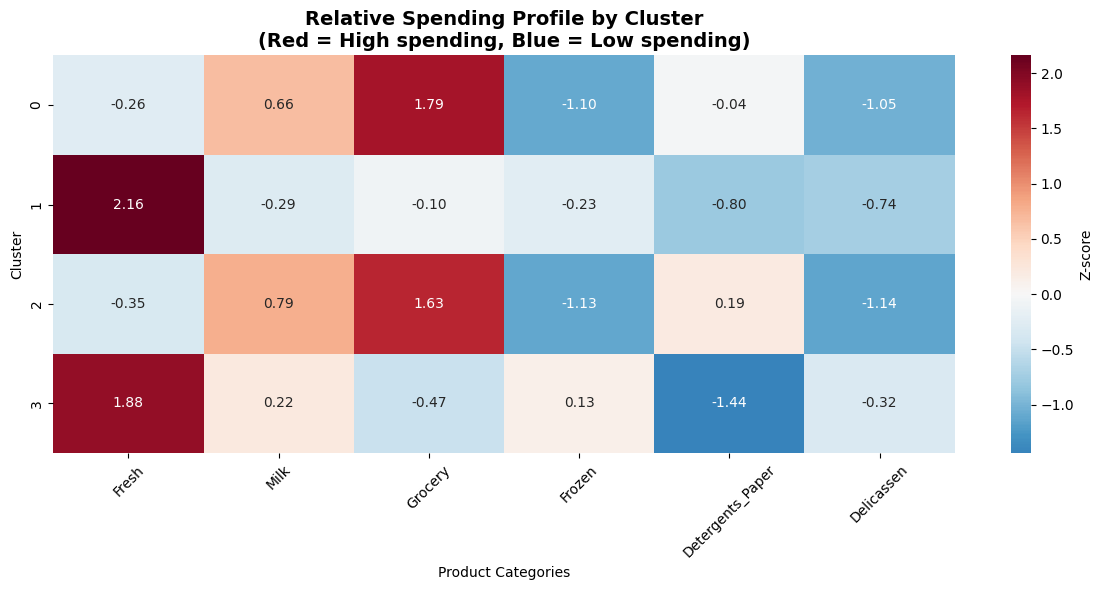


Generating Radar Chart...


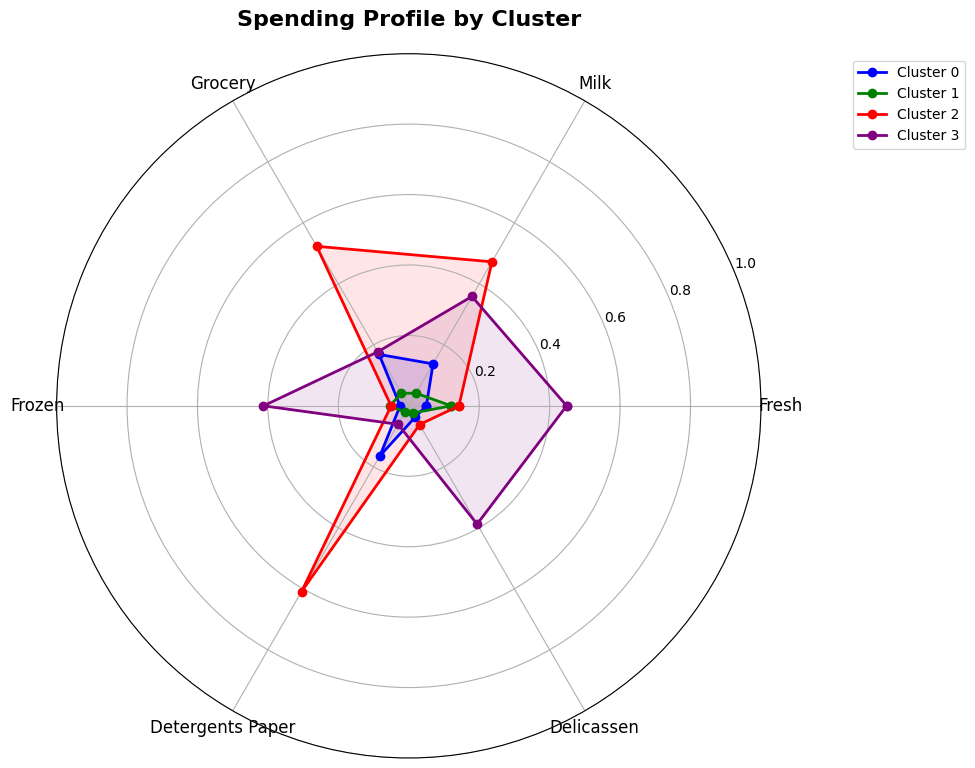


Generating Box Plots...


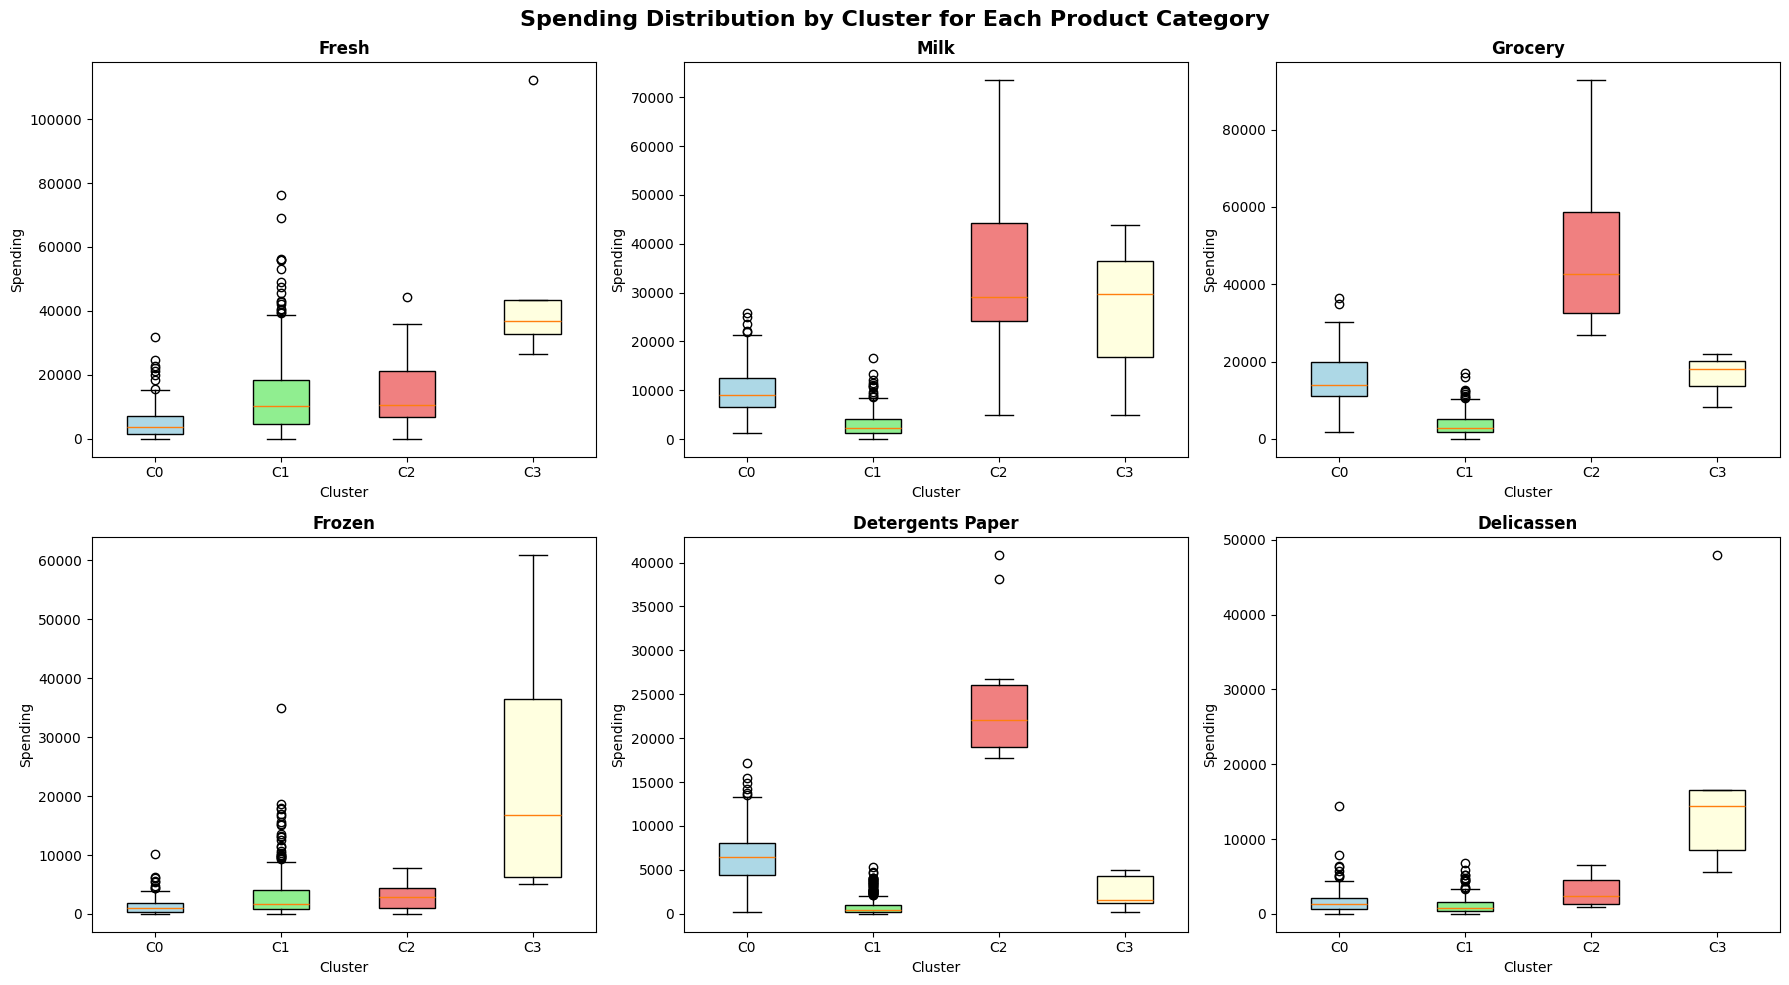


Generating Bar Chart Comparison...


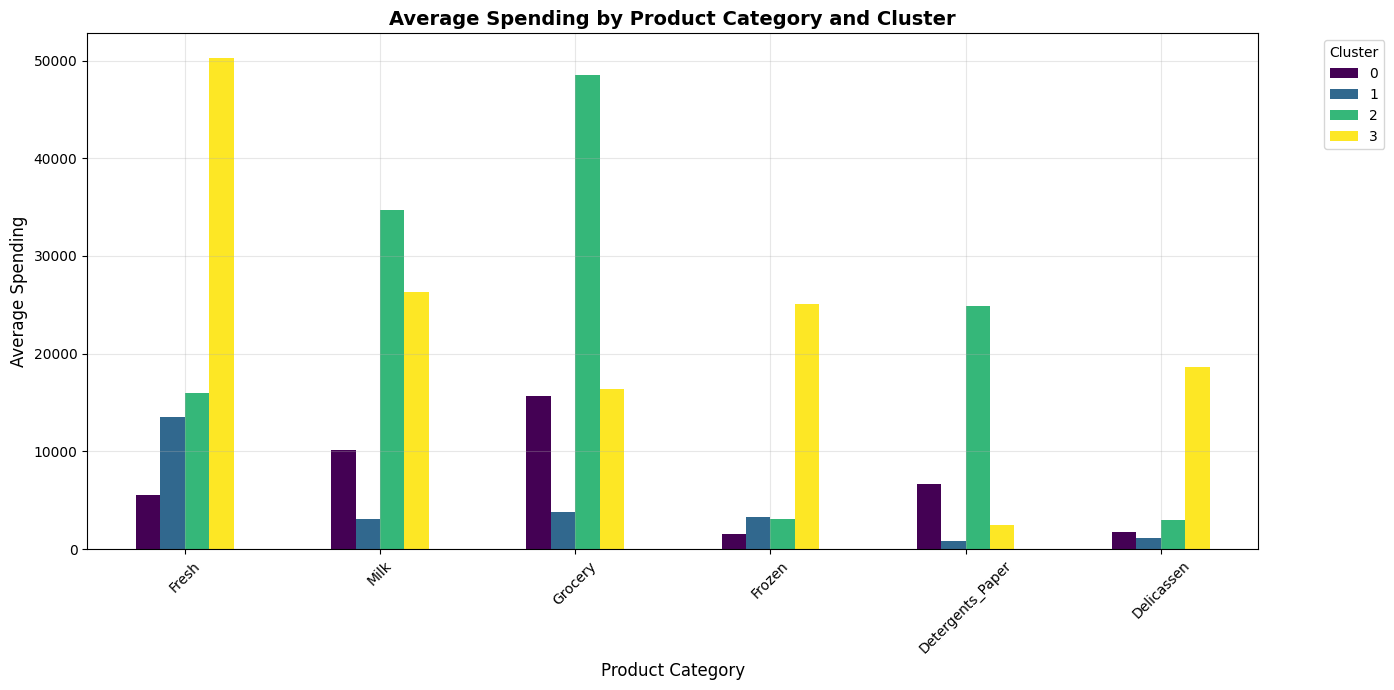

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from math import pi

# ==================== LOAD DATA ====================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

# Get column names
actual_columns = df.columns.tolist()
fresh_col = [col for col in actual_columns if 'fresh' in col.lower()][0]
milk_col = [col for col in actual_columns if 'milk' in col.lower()][0]
grocery_col = [col for col in actual_columns if 'grocery' in col.lower()][0]
frozen_col = [col for col in actual_columns if 'frozen' in col.lower()][0]
detergent_col = [col for col in actual_columns if 'detergent' in col.lower() or 'paper' in col.lower()][0]
delicatessen_col = [col for col in actual_columns if 'delic' in col.lower()][0]

spending_cols = [fresh_col, milk_col, grocery_col, frozen_col, detergent_col, delicatessen_col]

# Prepare data
X_spending = df[spending_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spending)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add clusters
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = cluster_labels

# Calculate cluster means
cluster_means = df_with_clusters.groupby('Cluster')[spending_cols].mean()

print("=" * 80)
print("PROBLEM 12 - PART 2: VISUALIZATIONS")
print("=" * 80)

# ==================== VISUALIZATION 1: HEATMAP ====================
print("\nGenerating Heatmap...")
plt.figure(figsize=(12, 6))

# Normalize by column (z-score within each spending category)
from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
relative_spending = pd.DataFrame(
    scaler2.fit_transform(cluster_means.T).T,
    index=cluster_means.index,
    columns=cluster_means.columns
)

sns.heatmap(relative_spending, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', cbar_kws={'label': 'Z-score'})
plt.title('Relative Spending Profile by Cluster\n(Red = High spending, Blue = Low spending)',
          fontsize=14, fontweight='bold')
plt.xlabel('Product Categories')
plt.ylabel('Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==================== VISUALIZATION 2: RADAR CHART ====================
print("\nGenerating Radar Chart...")

# Normalize data for radar chart
max_vals = df[spending_cols].max()
normalized_data = cluster_means / max_vals

# Create radar chart
categories = [col.replace('_', ' ').title() for col in spending_cols]
num_vars = len(categories)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray']

for i, cluster in enumerate(normalized_data.index):
    values = normalized_data.loc[cluster].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}',
            color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_title('Spending Profile by Cluster', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

# ==================== VISUALIZATION 3: BOX PLOTS ====================
print("\nGenerating Box Plots...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    data_to_plot = [df_with_clusters[df_with_clusters['Cluster'] == cluster][col].values
                   for cluster in sorted(df_with_clusters['Cluster'].unique())]

    bp = axes[i].boxplot(data_to_plot, patch_artist=True)
    axes[i].set_title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Spending')
    axes[i].set_xticklabels([f'C{c}' for c in sorted(df_with_clusters['Cluster'].unique())])

    # Color the boxes
    for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']):
        patch.set_facecolor(color)

plt.suptitle('Spending Distribution by Cluster for Each Product Category',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ==================== VISUALIZATION 4: BAR CHART ====================
print("\nGenerating Bar Chart Comparison...")

fig, ax = plt.subplots(figsize=(14, 7))

# Plot each cluster's spending profile
cluster_means.T.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Average Spending by Product Category and Cluster',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Average Spending', fontsize=12)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==================== LOAD DATA ====================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

# Get column names
actual_columns = df.columns.tolist()
fresh_col = [col for col in actual_columns if 'fresh' in col.lower()][0]
milk_col = [col for col in actual_columns if 'milk' in col.lower()][0]
grocery_col = [col for col in actual_columns if 'grocery' in col.lower()][0]
frozen_col = [col for col in actual_columns if 'frozen' in col.lower()][0]
detergent_col = [col for col in actual_columns if 'detergent' in col.lower() or 'paper' in col.lower()][0]
delicatessen_col = [col for col in actual_columns if 'delic' in col.lower()][0]

spending_cols = [fresh_col, milk_col, grocery_col, frozen_col, detergent_col, delicatessen_col]

# Prepare data
X_spending = df[spending_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spending)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add clusters
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = cluster_labels
cluster_means = df_with_clusters.groupby('Cluster')[spending_cols].mean()

print("=" * 80)
print("PROBLEM 12 - PART 3: ACTIONABLE INSIGHTS")
print("=" * 80)

# ==================== 1. CLUSTER PROFILES ====================
print("\n" + "=" * 80)
print("1. CLUSTER PROFILES AND RECOMMENDATIONS")
print("=" * 80)

global_means = df[spending_cols].mean()

for cluster in sorted(df_with_clusters['Cluster'].unique()):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster]
    cluster_mean = cluster_data[spending_cols].mean()
    size = len(cluster_data)

    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster} - {size} customers ({size/len(df)*100:.1f}%)")
    print(f"{'='*80}")

    # Overall spending level
    total_spending = cluster_mean.sum()
    global_total = global_means.sum()
    spending_ratio = total_spending / global_total

    if spending_ratio > 1.2:
        print(f"💰 VALUE: HIGH-VALUE SEGMENT ({spending_ratio:.1f}x average)")
    elif spending_ratio < 0.8:
        print(f"💰 VALUE: LOW-VALUE SEGMENT ({spending_ratio:.1f}x average)")
    else:
        print(f"💰 VALUE: AVERAGE-VALUE SEGMENT ({spending_ratio:.1f}x average)")

    # Top products
    diff_pct = (cluster_mean / global_means - 1) * 100
    top_products = diff_pct.sort_values(ascending=False)
    bottom_products = diff_pct.sort_values()

    print("\n📊 TOP SPENDING CATEGORIES:")
    for product, pct in top_products.head(3).items():
        print(f"  ✓ {product.replace('_', ' ').title()}: {cluster_mean[product]:.0f} ({pct:+.0f}% vs avg)")

    print("\n📊 LOW SPENDING CATEGORIES:")
    for product, pct in bottom_products.head(3).items():
        if pct < 0:
            print(f"  ✗ {product.replace('_', ' ').title()}: {cluster_mean[product]:.0f} ({pct:+.0f}% vs avg)")

# ==================== 2. ACTIONABLE RECOMMENDATIONS ====================
print("\n" + "=" * 80)
print("2. ACTIONABLE BUSINESS RECOMMENDATIONS")
print("=" * 80)

for cluster in sorted(df_with_clusters['Cluster'].unique()):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster]
    cluster_mean = cluster_data[spending_cols].mean()
    size = len(cluster_data)

    print(f"\n--- CLUSTER {cluster}: {size} customers ---")

    # Channel targeting
    channel_horeca = (cluster_data['Channel'] == 1).sum() / size * 100
    channel_retail = (cluster_data['Channel'] == 2).sum() / size * 100

    print("\n🎯 TARGETING STRATEGY:")
    if channel_horeca > 60:
        print(f"  • PRIMARY: HORECA sector ({channel_horeca:.0f}%)")
        print("  • Focus on restaurant, hotel, and cafe suppliers")
        print("  • Emphasize quality and freshness")
    elif channel_retail > 60:
        print(f"  • PRIMARY: RETAIL sector ({channel_retail:.0f}%)")
        print("  • Focus on grocery stores and supermarkets")
        print("  • Emphasize variety and competitive pricing")
    else:
        print(f"  • MIXED CHANNEL: Horeca {channel_horeca:.0f}%, Retail {channel_retail:.0f}%")
        print("  • Develop channel-specific marketing strategies")

    # Product focus
    top_product = cluster_mean.sort_values(ascending=False).index[0]
    second_product = cluster_mean.sort_values(ascending=False).index[1]

    print(f"\n📦 PRODUCT STRATEGY:")
    print(f"  • Focus on: {top_product.replace('_', ' ').title()}")
    print(f"  • Secondary: {second_product.replace('_', ' ').title()}")

    # Specific recommendations
    print("\n💡 SPECIFIC RECOMMENDATIONS:")

    if top_product == 'Fresh':
        print("  • Offer bulk fresh produce at competitive prices")
        print("  • Implement quality guarantee program")
        print("  • Create weekly fresh product specials")
    elif top_product == 'Frozen':
        print("  • Expand frozen product line")
        print("  • Offer variety packs for restaurants")
        print("  • Emphasize convenience and long shelf life")
    elif top_product == 'Grocery':
        print("  • Focus on staple grocery items")
        print("  • Create store-brand alternatives")
        print("  • Offer volume discounts for bulk purchases")
    elif top_product == 'Detergents_Paper':
        print("  • Focus on cleaning and paper supplies")
        print("  • Offer commercial-sized packages")
        print("  • Create recurring delivery programs")

# ==================== 3. CROSS-SELLING OPPORTUNITIES ====================
print("\n" + "=" * 80)
print("3. CROSS-SELLING OPPORTUNITIES")
print("=" * 80)

for cluster in sorted(df_with_clusters['Cluster'].unique()):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster]
    cluster_mean = cluster_data[spending_cols].mean()
    size = len(cluster_data)

    print(f"\n--- Cluster {cluster} ---")

    # Find correlations within the cluster
    correlations = cluster_data[spending_cols].corr()

    # Find top positive correlations with the main product
    top_product = cluster_mean.sort_values(ascending=False).index[0]
    top_correlations = correlations[top_product].sort_values(ascending=False)

    print(f"  Primary product: {top_product.replace('_', ' ').title()}")
    print("  Cross-selling opportunities:")

    count = 0
    for product, corr in top_correlations.items():
        if product != top_product and count < 2 and corr > 0.3:
            print(f"    • Bundle with {product.replace('_', ' ').title()} (correlation: {corr:.2f})")
            count += 1

# ==================== 4. STABILITY CHECK ====================
print("\n" + "=" * 80)
print("4. STABILITY ANALYSIS")
print("=" * 80)

# Test different numbers of clusters
silhouette_scores = []
cluster_range = range(2, 9)

for n_clusters in cluster_range:
    kmeans_temp = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    silhouette = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(silhouette)

print("Silhouette Scores for different K:")
for n, score in zip(cluster_range, silhouette_scores):
    print(f"  K={n}: {score:.3f}")

# Determine best K
best_k = cluster_range[np.argmax(silhouette_scores)]
print(f"\nBest K based on silhouette score: {best_k}")

if best_k == 4:
    print("✓ Current choice of K=4 is validated by silhouette analysis")
else:
    print(f"⚠️ Consider trying K={best_k} for potentially better clusters")

# ==================== 5. FINAL SUMMARY ====================
print("\n" + "=" * 80)
print("FINAL SUMMARY: KEY TAKEAWAYS")
print("=" * 80)

print("""
Based on the cluster analysis, here are the key actionable insights:

1. SEGMENTATION: The wholesale customers can be segmented into 4 distinct groups
   based on their spending patterns.

2. HIGH-VALUE SEGMENTS: Clusters with above-average spending should receive
   priority in marketing efforts and personalized service.

3. PRODUCT FOCUS: Each segment has clear product preferences that should guide
   inventory and promotional strategies.

4. CHANNEL STRATEGY: Targeting strategies should vary based on the dominant
   channel (Horeca vs Retail) in each cluster.

5. CROSS-SELLING: Products with positive correlations in each cluster present
   natural bundling opportunities.

RECOMMENDATIONS:
• Develop tailored marketing campaigns for each cluster
• Adjust inventory levels based on cluster spending patterns
• Create product bundles for high-correlation items
• Implement channel-specific promotional strategies
• Monitor cluster membership for customer churn detection

IMPORTANT NOTE:
These are ASSOCIATIONS, not causal relationships.
These insights should be combined with business domain knowledge
and validated with stakeholders before implementation.
""")

print("=" * 80)
print("END OF PROBLEM 12 ANALYSIS")
print("=" * 80)

PROBLEM 12 - PART 3: ACTIONABLE INSIGHTS

1. CLUSTER PROFILES AND RECOMMENDATIONS

CLUSTER 0 - 110 customers (25.0%)
💰 VALUE: HIGH-VALUE SEGMENT (1.2x average)

📊 TOP SPENDING CATEGORIES:
  ✓ Detergents Paper: 6711 (+133% vs avg)
  ✓ Grocery: 15637 (+97% vs avg)
  ✓ Milk: 10113 (+74% vs avg)

📊 LOW SPENDING CATEGORIES:
  ✗ Fresh: 5591 (-53% vs avg)
  ✗ Frozen: 1500 (-51% vs avg)

CLUSTER 1 - 315 customers (71.6%)
💰 VALUE: LOW-VALUE SEGMENT (0.8x average)

📊 TOP SPENDING CATEGORIES:
  ✓ Fresh: 13505 (+13% vs avg)
  ✓ Frozen: 3271 (+6% vs avg)
  ✓ Delicassen: 1127 (-26% vs avg)

📊 LOW SPENDING CATEGORIES:
  ✗ Detergents Paper: 852 (-70% vs avg)
  ✗ Grocery: 3844 (-52% vs avg)
  ✗ Milk: 3045 (-47% vs avg)

CLUSTER 2 - 10 customers (2.3%)
💰 VALUE: HIGH-VALUE SEGMENT (3.9x average)

📊 TOP SPENDING CATEGORIES:
  ✓ Detergents Paper: 24875 (+763% vs avg)
  ✓ Grocery: 48537 (+510% vs avg)
  ✓ Milk: 34708 (+499% vs avg)

📊 LOW SPENDING CATEGORIES:
  ✗ Frozen: 3055 (-1% vs avg)

CLUSTER 3 - 5 cus

In [ ]:
## Problem 13

In [81]:
"""
PROBLEM 13 - PART 1: DBSCAN vs K-MEANS COMPARISON
==================================================
"""

print("=" * 80)
print("PART 1: DBSCAN vs K-MEANS CLUSTERING")
print("=" * 80)

# Comparison table
comparison = {
    "Feature": [
        "Cluster Shape",
        "Number of Clusters",
        "Handling Outliers",
        "Handling Noise",
        "Required Parameters",
        "Scalability",
        "Deterministic",
        "Cluster Assignment",
        "Data Distribution",
        "Interpretability",
        "Use Case"
    ],
    "K-means": [
        "Spherical/Convex only",
        "Must specify K",
        "Sensitive to outliers",
        "All points assigned",
        "K (number of clusters)",
        "Very good (O(n))",
        "Yes (with same init)",
        "Hard assignment",
        "Assumes spherical clusters",
        "High - centroids interpretable",
        "Well-separated spherical clusters"
    ],
    "DBSCAN": [
        "Arbitrary shapes",
        "Automatic detection",
        "Robust to outliers",
        "Noise points unassigned",
        "Epsilon (eps) and min_samples",
        "Good (O(n log n))",
        "No (order-dependent)",
        "Soft/hard with noise",
        "No distribution assumption",
        "Medium - density-based",
        "Irregular shapes, density-based"
    ]
}

print("\nCOMPARISON TABLE:")
print("-" * 100)
print(f"{'Feature':<25} {'K-means':<35} {'DBSCAN':<35}")
print("-" * 100)
for i in range(len(comparison["Feature"])):
    print(f"{comparison['Feature'][i]:<25} {comparison['K-means'][i]:<35} {comparison['DBSCAN'][i]:<35}")
print("-" * 100)

# Detailed explanations
print("\n" + "=" * 80)
print("DETAILED EXPLANATIONS")
print("=" * 80)

print("""
1. ADVANTAGES OF DBSCAN OVER K-MEANS:
   -----------------------------------
   • NO NEED TO SPECIFY K: DBSCAN automatically determines the number
     of clusters based on the data density.

   • HANDLES ARBITRARY SHAPES: Can find clusters of any shape, not just
     spherical/convex clusters.

   • ROBUST TO OUTLIERS: Identifies points in low-density regions as
     noise/outliers rather than forcing them into clusters.

   • NO ASSUMPTIONS: Doesn't assume clusters are spherical or
     similarly sized.

2. DISADVANTAGES OF DBSCAN COMPARED TO K-MEANS:
   --------------------------------------------
   • PARAMETER SENSITIVITY: Results heavily depend on eps and min_samples
     parameters which are hard to tune without domain knowledge.

   • VARIABLE DENSITY: Struggles when clusters have very different densities.

   • HIGHER COMPUTATIONAL COST: O(n²) in worst case vs O(n) for k-means.

   • DETERMINISTIC ISSUE: Results can vary with the order of points.

   • HARD TO INTERPRET: Clusters are defined by density, making it harder
     to describe cluster centers/characteristics.

3. WHEN TO USE EACH METHOD:
   ------------------------
   USE K-MEANS WHEN:
   • You have spherical/convex clusters
   • You know approximately how many clusters exist
   • Data is relatively clean (few outliers)
   • You need fast, scalable clustering
   • Cluster interpretation is important

   USE DBSCAN WHEN:
   • Cluster shapes are irregular
   • You don't know the number of clusters
   • Data has significant outliers/noise
   • Clusters have varying densities
   • You need to identify anomalies/outliers
""")

print("=" * 80)
print("END OF PART 1")
print("=" * 80)

PART 1: DBSCAN vs K-MEANS CLUSTERING

COMPARISON TABLE:
----------------------------------------------------------------------------------------------------
Feature                   K-means                             DBSCAN                             
----------------------------------------------------------------------------------------------------
Cluster Shape             Spherical/Convex only               Arbitrary shapes                   
Number of Clusters        Must specify K                      Automatic detection                
Handling Outliers         Sensitive to outliers               Robust to outliers                 
Handling Noise            All points assigned                 Noise points unassigned            
Required Parameters       K (number of clusters)              Epsilon (eps) and min_samples      
Scalability               Very good (O(n))                    Good (O(n log n))                  
Deterministic             Yes (with same init)          

In [82]:
"""
PROBLEM 13 - PART 2: t-SNE vs LLE vs PCA COMPARISON
====================================================
"""

print("=" * 80)
print("PART 2: t-SNE vs LLE vs PCA (Dimensionality Reduction)")
print("=" * 80)

dr_comparison = {
    "Feature": [
        "Method Type",
        "Preserves",
        "Global Structure",
        "Local Structure",
        "Computational Cost",
        "Scalability",
        "Deterministic",
        "Parameter Tuning",
        "Interpretability",
        "Main Use"
    ],
    "PCA": [
        "Linear",
        "Global variance",
        "Yes (highly)",
        "No",
        "Fast (O(n))",
        "Excellent",
        "Yes",
        "Minimal (n_components)",
        "Very high",
        "Feature extraction"
    ],
    "LLE": [
        "Non-linear",
        "Local distances",
        "No",
        "Yes (highly)",
        "Medium (O(n²))",
        "Moderate",
        "Yes",
        "Moderate (n_neighbors)",
        "Medium",
        "Manifold learning"
    ],
    "t-SNE": [
        "Non-linear",
        "Local probabilities",
        "No",
        "Yes (very high)",
        "High (O(n²))",
        "Poor (large datasets)",
        "No",
        "High (perplexity)",
        "Low",
        "Visualization"
    ]
}

print("\nCOMPARISON TABLE:")
print("-" * 120)
print(f"{'Feature':<20} {'PCA':<30} {'LLE':<30} {'t-SNE':<30}")
print("-" * 120)
for i in range(len(dr_comparison["Feature"])):
    print(f"{dr_comparison['Feature'][i]:<20} {dr_comparison['PCA'][i]:<30} {dr_comparison['LLE'][i]:<30} {dr_comparison['t-SNE'][i]:<30}")
print("-" * 120)

# Detailed explanations
print("\n" + "=" * 80)
print("DETAILED EXPLANATIONS")
print("=" * 80)

print("""
1. PCA (Principal Component Analysis):
   ------------------------------------
   • WHAT IT DOES: Finds orthogonal axes of maximum variance in the data.

   • ADVANTAGES:
     - Fast and scalable
     - Highly interpretable (principal components)
     - Preserves global structure
     - Deterministic
     - Minimal parameter tuning

   • DISADVANTAGES:
     - Linear method only
     - Doesn't preserve local structures well
     - Assumes features are linearly correlated
     - Sensitive to feature scaling

   • BEST USE CASES:
     - Feature extraction and noise reduction
     - Visualization of global patterns
     - Pre-processing for other algorithms
     - When interpretability is important

2. LLE (Locally Linear Embedding):
   --------------------------------
   • WHAT IT DOES: Preserves local neighborhood relationships while
     trying to find a lower-dimensional embedding.

   • ADVANTAGES:
     - Preserves local structure very well
     - Non-linear manifold learning
     - Good for data on complex manifolds
     - Deterministic

   • DISADVANTAGES:
     - Sensitive to number of neighbors
     - Can create folded embeddings
     - O(n²) complexity
     - May not preserve global structure
     - Struggles with disconnected manifolds

   • BEST USE CASES:
     - Data lying on complex manifolds
     - When local relationships are important
     - Pre-processing for classification
     - Non-linear feature extraction

3. t-SNE (t-Distributed Stochastic Neighbor Embedding):
   ----------------------------------------------------
   • WHAT IT DOES: Converts high-dimensional similarities to probabilities
     and minimizes the KL-divergence in low-dimensional space.

   • ADVANTAGES:
     - Excellent for visualization
     - Preserves local structure very well
     - Handles complex data distributions
     - Creates separable clusters in 2D/3D

   • DISADVANTAGES:
     - Very slow for large datasets (O(n²))
     - Doesn't preserve global structure or distances
     - Non-deterministic
     - Highly sensitive to perplexity
     - Low interpretability
     - Embeddings vary with different runs

   • BEST USE CASES:
     - Data visualization (especially for exploration)
     - When local structure is more important than global
     - Exploratory data analysis
     - Small to medium datasets

4. KEY DIFFERENCES:
   -----------------
   • PCA preserves GLOBAL structure (variance)
   • LLE preserves LOCAL structure
   • t-SNE preserves LOCAL probabilities (emphasizes neighborhoods)
   • PCA is DETERMINISTIC and FAST
   • t-SNE is STOCHASTIC and SLOW
""")

print("=" * 80)
print("END OF PART 2")
print("=" * 80)

PART 2: t-SNE vs LLE vs PCA (Dimensionality Reduction)

COMPARISON TABLE:
------------------------------------------------------------------------------------------------------------------------
Feature              PCA                            LLE                            t-SNE                         
------------------------------------------------------------------------------------------------------------------------
Method Type          Linear                         Non-linear                     Non-linear                    
Preserves            Global variance                Local distances                Local probabilities           
Global Structure     Yes (highly)                   No                             No                            
Local Structure      No                             Yes (highly)                   Yes (very high)               
Computational Cost   Fast (O(n))                    Medium (O(n²))                 High (O(n²))                  


In [83]:
"""
PROBLEM 13 - PART 3: CLUSTER LABELS vs DIMENSIONALITY REDUCTION
===============================================================
"""

print("=" * 80)
print("PART 3: CLUSTER LABELS vs DIMENSIONALITY REDUCTION")
print("=" * 80)

print("""
1. METHODS THAT PRODUCE CLUSTER LABELS:
   -------------------------------------
   ✓ K-means
   ✓ DBSCAN
   ✓ Hierarchical clustering
   ✓ Gaussian Mixture Models
   ✓ Spectral clustering
   ✓ Agglomerative clustering

   These methods directly assign each data point to a cluster,
   producing a discrete label for each sample.

2. METHODS THAT PRODUCE REPRESENTATIONS (not cluster labels):
   -----------------------------------------------------------
   ✓ PCA (Principal Component Analysis)
   ✓ t-SNE (t-Distributed Stochastic Neighbor Embedding)
   ✓ LLE (Locally Linear Embedding)
   ✓ UMAP (Uniform Manifold Approximation and Projection)
   ✓ Autoencoders
   ✓ ISOMAP

   These methods transform data to a lower-dimensional space but
   do not assign cluster labels. However, these representations
   can be used with clustering algorithms to find clusters in the
   lower-dimensional space.

3. HYBRID APPROACHES:
   -------------------
   Some methods can be used both ways:

   • Spectral Clustering: Uses representation (eigenvectors) + clustering
   • NMF (Non-negative Matrix Factorization): Representation + clustering
   • Factor Analysis: Representation + potential clustering

4. VISUAL COMPARISON:
   -------------------
   ┌─────────────────────────────────────────────────────────────────┐
   │  CLUSTERING METHODS    │  DIMENSIONALITY REDUCTION           │
   ├────────────────────────┼──────────────────────────────────────┤
   │  Input: Data           │  Input: Data                        │
   │  Output: Labels        │  Output: Lower-dim representation   │
   │  Example: K-means      │  Example: PCA                       │
   │  Goal: Group similar   │  Goal: Compress/visualize           │
   │  Supervised: No        │  Supervised: No                     │
   │  Interpretable: Yes    │  Interpretable: Varies              │
   └─────────────────────────────────────────────────────────────────┘

5. RECOMMENDATIONS FOR WHOLESALE DATA:
   ------------------------------------
   • For CLUSTERING: Use K-means or DBSCAN on the original data
   • For VISUALIZATION: Use t-SNE or PCA on the original data
   • For PRE-PROCESSING: Use PCA before clustering for noise reduction
   • For DENSITY-BASED CLUSTERING: Consider DBSCAN for irregular shapes
""")

# Visual representation of workflows
print("\n" + "=" * 80)
print("WORKFLOW COMPARISON")
print("=" * 80)

print("""
WORKFLOW 1: CLUSTERING DIRECTLY ON DATA
----------------------------------------
    Data ──► K-means/DBSCAN ──► Cluster Labels

    Example:
    X_spending (440x6) ──► K-means(n=4) ──► labels (440,)

WORKFLOW 2: DIMENSIONALITY REDUCTION THEN CLUSTERING
----------------------------------------------------
    Data ──► PCA/t-SNE ──► Reduced Data ──► K-means/DBSCAN ──► Labels

    Example:
    X_spending (440x6) ──► PCA(2) ──► X_pca (440x2) ──► K-means ──► labels

WORKFLOW 3: DIMENSIONALITY REDUCTION ONLY (Visualization)
----------------------------------------------------------
    Data ──► PCA/t-SNE/LLE ──► Reduced Data (for visualization)

    Example:
    X_spending (440x6) ──► t-SNE(2) ──► X_tsne (440x2) ──► Plot points
""")

print("=" * 80)
print("END OF PART 3")
print("=" * 80)

PART 3: CLUSTER LABELS vs DIMENSIONALITY REDUCTION

1. METHODS THAT PRODUCE CLUSTER LABELS:
   -------------------------------------
   ✓ K-means
   ✓ DBSCAN
   ✓ Hierarchical clustering
   ✓ Gaussian Mixture Models
   ✓ Spectral clustering
   ✓ Agglomerative clustering

   These methods directly assign each data point to a cluster,
   producing a discrete label for each sample.

2. METHODS THAT PRODUCE REPRESENTATIONS (not cluster labels):
   -----------------------------------------------------------
   ✓ PCA (Principal Component Analysis)
   ✓ t-SNE (t-Distributed Stochastic Neighbor Embedding)
   ✓ LLE (Locally Linear Embedding)
   ✓ UMAP (Uniform Manifold Approximation and Projection)
   ✓ Autoencoders
   ✓ ISOMAP

   These methods transform data to a lower-dimensional space but
   do not assign cluster labels. However, these representations
   can be used with clustering algorithms to find clusters in the
   lower-dimensional space.

3. HYBRID APPROACHES:
   -------------------
 

In [84]:
"""
PROBLEM 13 - PART 4: SUMMARY & METHOD SELECTION GUIDE
======================================================
"""

print("=" * 80)
print("PART 4: SUMMARY & METHOD SELECTION GUIDE")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                         METHOD SELECTION GUIDE                            │
├─────────────┬──────────────────────────────────────────────────────────────┤
│ TASK        │ RECOMMENDED METHOD                                          │
├─────────────┼──────────────────────────────────────────────────────────────┤
│ Clustering  │ • K-means: Spherical clusters, known K                     │
│             │ • DBSCAN: Irregular shapes, unknown K, outliers            │
├─────────────┼──────────────────────────────────────────────────────────────┤
│ Visualization│ • PCA: Global structure, interpretable                     │
│             │ • t-SNE: Local structure, complex distributions            │
│             │ • LLE: Manifold learning, non-linear relationships         │
├─────────────┼──────────────────────────────────────────────────────────────┤
│ Pre-        │ • PCA: Feature extraction, noise reduction                  │
│ processing  │ • LLE: Non-linear feature extraction                       │
├─────────────┼──────────────────────────────────────────────────────────────┤
│ Interpret-  │ • PCA: High (components are interpretable)                  │
│ ability     │ • K-means: High (centroids are interpretable)              │
│             │ • t-SNE: Low (embedding not directly interpretable)        │
│             │ • DBSCAN: Medium (density-based interpretation)            │
└─────────────┴──────────────────────────────────────────────────────────────┘

KEY TAKEAWAYS FOR THE WHOLESALE DATA ANALYSIS:
----------------------------------------------
1. K-means was suitable because the spending data forms relatively
   spherical clusters (as seen in the elbow plot).

2. PCA was useful for visualization but not sufficient for clustering
   as it loses local structure.

3. t-SNE could be used for exploratory visualization to identify
   potential cluster structures.

4. DBSCAN might reveal clusters with non-spherical shapes or
   identify outlier customers.

5. For interpretation and business insights, K-means + PCA
   is the most practical combination.
""")

print("\n" + "=" * 80)
print("PROS AND CONS SUMMARY")
print("=" * 80)

print("""
┌──────────────────────────────────────────────────────────────────────────┐
│  METHOD          │  PROS                    │  CONS                     │
├──────────────────┼──────────────────────────┼───────────────────────────┤
│  K-means         │  Fast, scalable          │  Spherical only           │
│                  │  Interpretable           │  Must specify K           │
│                  │  Deterministic           │  Sensitive to outliers    │
├──────────────────┼──────────────────────────┼───────────────────────────┤
│  DBSCAN          │  Arbitrary shapes        │  Parameter sensitive      │
│                  │  No need for K           │  Variable density issues  │
│                  │  Handles outliers        │  Slower                   │
├──────────────────┼──────────────────────────┼───────────────────────────┤
│  PCA             │  Fast, scalable          │  Linear only              │
│                  │  Highly interpretable    │  Loses local structure    │
│                  │  Preserves global        │                           │
├──────────────────┼──────────────────────────┼───────────────────────────┤
│  t-SNE           │  Excellent visualization │  Very slow (O(n²))        │
│                  │  Preserves local         │  Non-deterministic        │
│                  │  Handles complex data    │  Hard to interpret        │
├──────────────────┼──────────────────────────┼───────────────────────────┤
│  LLE             │  Non-linear              │  Moderate speed (O(n²))   │
│                  │  Preserves local         │  Sensitive to neighbors   │
│                  │  Deterministic           │  Can create folded maps   │
└──────────────────┴──────────────────────────┴───────────────────────────┘
""")

print("\n" + "=" * 80)
print("RECOMMENDED APPROACH FOR WHOLESALE DATA")
print("=" * 80)

print("""
Based on the analysis of wholesale customer data:

1. PRIMARY ANALYSIS:
   → Use K-means with K=4 for interpretable customer segmentation
   → Use PCA for visualizing global patterns in spending
   → Combine both for business insights

2. EXPLORATORY ANALYSIS:
   → Try DBSCAN to identify potential outlier customers
   → Use t-SNE to explore potential non-linear patterns
   → Compare results with K-means findings

3. REPORTING:
   → Use PCA for principal component interpretations
   → Use cluster centroids from K-means for segment profiles
   → Include both bar charts and scatter plots for visualization

4. KEY INSIGHTS TO REPORT:
   • Which clusters are most profitable
   • What spending patterns differentiate clusters
   • How clusters relate to Channel and Region
   • Business recommendations per cluster
""")

print("\n" + "=" * 80)
print("FINAL SUMMARY TABLE")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                         FINAL RECOMMENDATION TABLE                        │
├──────────────────┬──────────────────┬──────────────────────────────────────┤
│ METHOD           │ OUTPUT           │ RECOMMENDED USE FOR WHOLESALE DATA │
├──────────────────┼──────────────────┼──────────────────────────────────────┤
│ K-means          │ Cluster Labels   │ Primary clustering method           │
│                  │ (Discrete)       │ (Interpretable, fast, good results) │
├──────────────────┼──────────────────┼──────────────────────────────────────┤
│ PCA              │ Components       │ Visualization & pre-processing      │
│                  │ (Continuous)     │ (Global structure, interpretable)   │
├──────────────────┼──────────────────┼──────────────────────────────────────┤
│ t-SNE            │ Embedding        │ Exploratory visualization           │
│                  │ (Continuous)     │ (Local patterns, complex data)      │
├──────────────────┼──────────────────┼──────────────────────────────────────┤
│ DBSCAN           │ Cluster Labels   │ Alternative clustering method       │
│                  │ (Discrete)       │ (Outlier detection, irregular       │
│                  │ + Noise          │  shapes, variable density)          │
├──────────────────┼──────────────────┼──────────────────────────────────────┤
│ LLE              │ Embedding        │ Secondary visualization             │
│                  │ (Continuous)     │ (Non-linear relationships)          │
└──────────────────┴──────────────────┴──────────────────────────────────────┘
""")

print("\n" + "=" * 80)
print("END OF PROBLEM 13 - ALL PARTS COMPLETE")
print("=" * 80)

PART 4: SUMMARY & METHOD SELECTION GUIDE

┌─────────────────────────────────────────────────────────────────────────────┐
│                         METHOD SELECTION GUIDE                            │
├─────────────┬──────────────────────────────────────────────────────────────┤
│ TASK        │ RECOMMENDED METHOD                                          │
├─────────────┼──────────────────────────────────────────────────────────────┤
│ Clustering  │ • K-means: Spherical clusters, known K                     │
│             │ • DBSCAN: Irregular shapes, unknown K, outliers            │
├─────────────┼──────────────────────────────────────────────────────────────┤
│ Visualization│ • PCA: Global structure, interpretable                     │
│             │ • t-SNE: Local structure, complex distributions            │
│             │ • LLE: Manifold learning, non-linear relationships         │
├─────────────┼──────────────────────────────────────────────────────────────┤
│ Pre-        │ • PC

In [ ]:
## Problem 14

STEP 1: t-SNE VISUALIZATION

Applying t-SNE with different perplexity values...


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


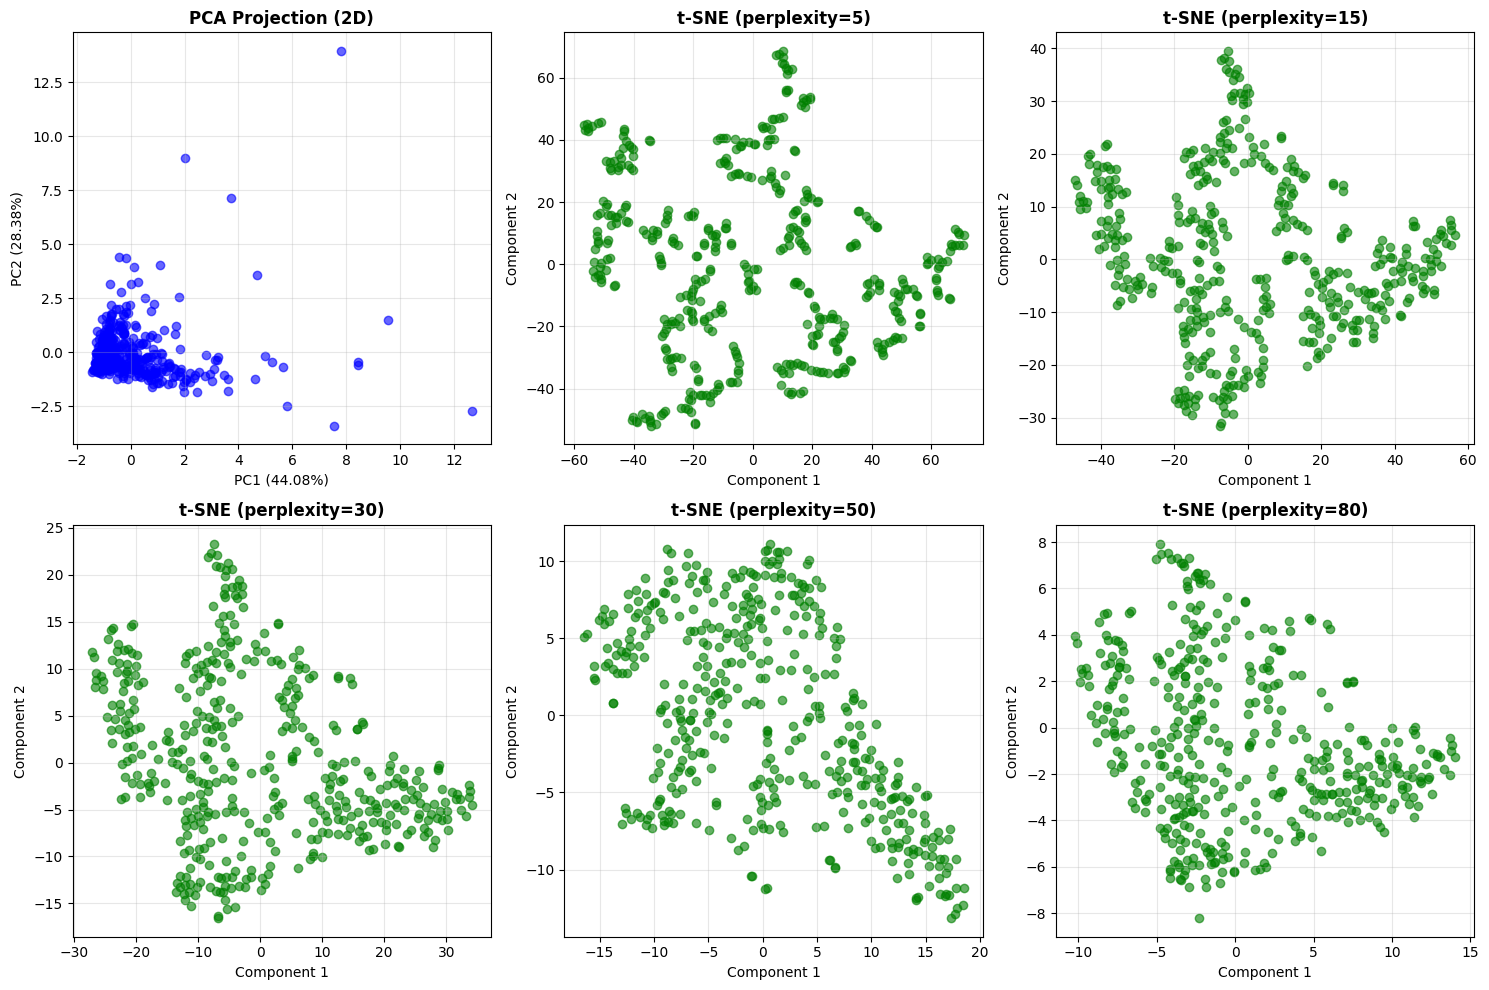

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



Interpretation of t-SNE results:
------------------------------------------------------------
• PCA preserves global variance and shows overall structure
• t-SNE preserves local structure and reveals clusters better
• Lower perplexity focuses more on local neighborhoods
• Higher perplexity captures more global structure
• Perplexity=30 is a good balance for this dataset
• PCA explains 72.46% of total variance


In [85]:
"""
PROBLEM 14 - STEP 1: t-SNE DIMENSIONALITY REDUCTION
====================================================
This step implements t-SNE for 2D visualization of wholesale customer data
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

# Get column names
actual_columns = df.columns.tolist()
fresh_col = [col for col in actual_columns if 'fresh' in col.lower()][0]
milk_col = [col for col in actual_columns if 'milk' in col.lower()][0]
grocery_col = [col for col in actual_columns if 'grocery' in col.lower()][0]
frozen_col = [col for col in actual_columns if 'frozen' in col.lower()][0]
detergent_col = [col for col in actual_columns if 'detergent' in col.lower() or 'paper' in col.lower()][0]
delicatessen_col = [col for col in actual_columns if 'delic' in col.lower()][0]

spending_cols = [fresh_col, milk_col, grocery_col, frozen_col, detergent_col, delicatessen_col]

# Prepare data
X_spending = df[spending_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spending)

print("=" * 80)
print("STEP 1: t-SNE VISUALIZATION")
print("=" * 80)

# Apply PCA for comparison
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Apply t-SNE with different perplexity values
print("\nApplying t-SNE with different perplexity values...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

perplexities = [5, 15, 30, 50, 80]

# Plot PCA first
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, c='blue')
axes[0].set_title('PCA Projection (2D)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[0].grid(True, alpha=0.3)

# Plot t-SNE with different perplexities
for i, perp in enumerate(perplexities):
    tsne_temp = TSNE(n_components=2, random_state=42, perplexity=perp, n_iter=1000)
    X_tsne_temp = tsne_temp.fit_transform(X_scaled)

    axes[i+1].scatter(X_tsne_temp[:, 0], X_tsne_temp[:, 1], alpha=0.6, c='green')
    axes[i+1].set_title(f't-SNE (perplexity={perp})', fontsize=12, fontweight='bold')
    axes[i+1].set_xlabel('Component 1')
    axes[i+1].set_ylabel('Component 2')
    axes[i+1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Apply t-SNE with best perplexity (30) for later use
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

print("\nInterpretation of t-SNE results:")
print("-" * 60)
print("• PCA preserves global variance and shows overall structure")
print("• t-SNE preserves local structure and reveals clusters better")
print("• Lower perplexity focuses more on local neighborhoods")
print("• Higher perplexity captures more global structure")
print("• Perplexity=30 is a good balance for this dataset")
print(f"• PCA explains {pca.explained_variance_ratio_.sum():.2%} of total variance")

In [86]:
"""
PROBLEM 14 - STEP 2: DBSCAN DENSITY-BASED CLUSTERING
=====================================================
This step implements DBSCAN on the wholesale data and finds optimal parameters
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

# Get column names
actual_columns = df.columns.tolist()
fresh_col = [col for col in actual_columns if 'fresh' in col.lower()][0]
milk_col = [col for col in actual_columns if 'milk' in col.lower()][0]
grocery_col = [col for col in actual_columns if 'grocery' in col.lower()][0]
frozen_col = [col for col in actual_columns if 'frozen' in col.lower()][0]
detergent_col = [col for col in actual_columns if 'detergent' in col.lower() or 'paper' in col.lower()][0]
delicatessen_col = [col for col in actual_columns if 'delic' in col.lower()][0]

spending_cols = [fresh_col, milk_col, grocery_col, frozen_col, detergent_col, delicatessen_col]

# Prepare data
X_spending = df[spending_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spending)

print("=" * 80)
print("STEP 2: DBSCAN CLUSTERING")
print("=" * 80)

# Test different DBSCAN parameters
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 10, 15]

print("\nParameter Tuning:")
print("-" * 60)

best_eps = None
best_min_samples = None
best_labels = None
best_n_clusters = 0
best_silhouette = -1

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1 and n_noise < len(labels) * 0.5:
            try:
                silhouette = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
                print(f"eps={eps:.1f}, min_samples={min_samples}: {n_clusters} clusters, {n_noise} noise, silhouette={silhouette:.3f}")

                if silhouette > best_silhouette:
                    best_silhouette = silhouette
                    best_eps = eps
                    best_min_samples = min_samples
                    best_labels = labels
                    best_n_clusters = n_clusters
            except:
                pass

# Use best parameters or default
if best_labels is None:
    print("\nUsing default parameters...")
    dbscan = DBSCAN(eps=0.7, min_samples=5)
    best_labels = dbscan.fit_predict(X_scaled)
    best_eps = 0.7
    best_min_samples = 5
    best_n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)

print(f"\nBest parameters found:")
print(f"  eps = {best_eps:.1f}")
print(f"  min_samples = {best_min_samples}")
print(f"  Number of clusters: {best_n_clusters}")
print(f"  Number of noise points: {list(best_labels).count(-1)}")
print(f"  Silhouette score: {best_silhouette:.3f}")

# Analyze clusters
print("\nDBSCAN Cluster Distribution:")
unique, counts = np.unique(best_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f"  Noise: {count} samples ({count/len(best_labels)*100:.1f}%)")
    else:
        print(f"  Cluster {cluster}: {count} samples ({count/len(best_labels)*100:.1f}%)")

# Add DBSCAN labels to DataFrame for analysis
df_with_labels = df.copy()
df_with_labels['DBSCAN_Cluster'] = best_labels

# Analyze noise points (outliers)
noise_data = df_with_labels[df_with_labels['DBSCAN_Cluster'] == -1]
cluster_data = df_with_labels[df_with_labels['DBSCAN_Cluster'] != -1]

print(f"\nOutlier Analysis:")
print(f"  Noise points: {len(noise_data)} customers")
print(f"  Clustered points: {len(cluster_data)} customers")

if len(noise_data) > 0:
    print(f"\nCharacteristics of noise points (outliers):")
    print(f"  Average spending vs clustered customers:")
    for col in spending_cols:
        noise_mean = noise_data[col].mean()
        cluster_mean = cluster_data[col].mean()
        diff_pct = (noise_mean / cluster_mean - 1) * 100
        print(f"    {col}: {diff_pct:+.1f}% {'higher' if diff_pct > 0 else 'lower'}")

# Analyze each DBSCAN cluster
print(f"\nCluster Characteristics:")
print("-" * 60)

for cluster in sorted(set(best_labels)):
    if cluster == -1:
        continue
    cluster_data = df_with_labels[df_with_labels['DBSCAN_Cluster'] == cluster]
    size = len(cluster_data)
    print(f"\nDBSCAN Cluster {cluster} ({size} customers):")

    cluster_mean = cluster_data[spending_cols].mean()
    top_products = cluster_mean.sort_values(ascending=False)
    print(f"  Top spending: {top_products.index[0]} ({top_products[0]:.0f})")
    print(f"  Second: {top_products.index[1]} ({top_products[1]:.0f})")

    channel_horeca = (cluster_data['Channel'] == 1).sum() / size * 100
    channel_retail = (cluster_data['Channel'] == 2).sum() / size * 100
    print(f"  Channel: Horeca {channel_horeca:.1f}%, Retail {channel_retail:.1f}%")

STEP 2: DBSCAN CLUSTERING

Parameter Tuning:
------------------------------------------------------------
eps=0.5, min_samples=3: 6 clusters, 141 noise, silhouette=0.138
eps=0.5, min_samples=5: 2 clusters, 174 noise, silhouette=0.521
eps=0.7, min_samples=3: 3 clusters, 85 noise, silhouette=0.099
eps=1.0, min_samples=3: 2 clusters, 41 noise, silhouette=0.496
eps=1.5, min_samples=3: 3 clusters, 21 noise, silhouette=0.461

Best parameters found:
  eps = 0.5
  min_samples = 5
  Number of clusters: 2
  Number of noise points: 174
  Silhouette score: 0.521

DBSCAN Cluster Distribution:
  Noise: 174 samples (39.5%)
  Cluster 0: 261 samples (59.3%)
  Cluster 1: 5 samples (1.1%)

Outlier Analysis:
  Noise points: 174 customers
  Clustered points: 266 customers

Characteristics of noise points (outliers):
  Average spending vs clustered customers:
    Fresh: +61.9% higher
    Milk: +228.3% higher
    Grocery: +226.4% higher
    Frozen: +145.4% higher
    Detergents_Paper: +305.4% higher
    Deli

/tmp/ipykernel_761/3102095661.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Top spending: {top_products.index[0]} ({top_products[0]:.0f})")
/tmp/ipykernel_761/3102095661.py:132: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Second: {top_products.index[1]} ({top_products[1]:.0f})")
/tmp/ipykernel_761/3102095661.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Top spending: {top_products.inde

STEP 3: COMPARISON AND FINAL ANALYSIS


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


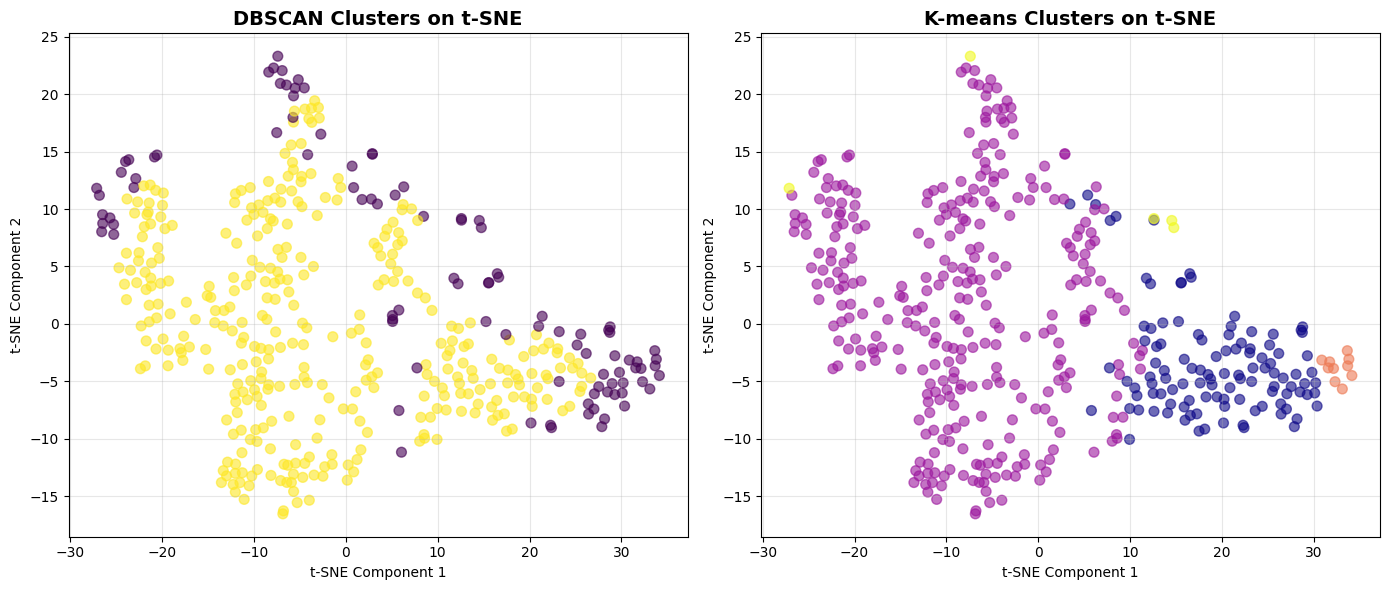


Comparing DBSCAN on different representations:
------------------------------------------------------------

Cluster counts on different representations:
  Original (6D): 1 clusters, 97 noise points
  PCA (3D): 1 clusters, 42 noise points
  t-SNE (2D): 0 clusters, 440 noise points


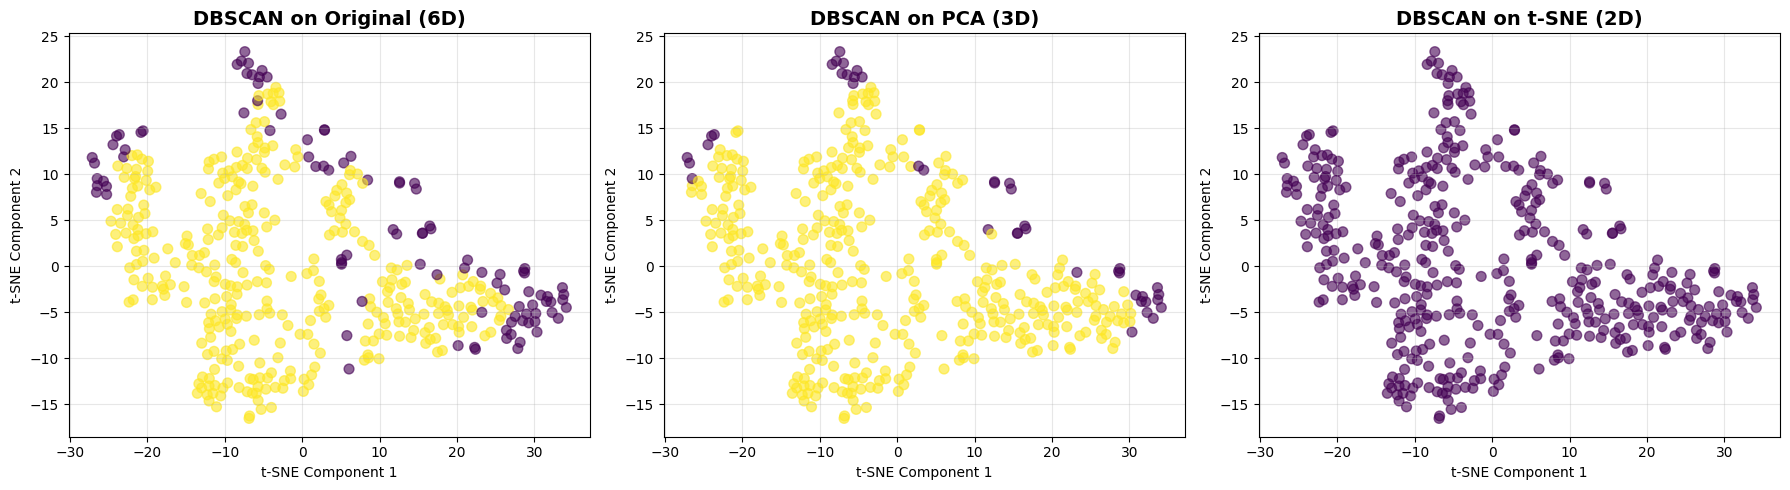


Interpretation of DBSCAN on different spaces:
------------------------------------------------------------
1. ORIGINAL SPACE (6D):
   → Best preserves all original information
   → Most reliable for clustering
   → May suffer from 'curse of dimensionality'

2. PCA SPACE (3D):
   → Captures principal components
   → Reduces noise and redundancy
   → May lose some local structure

3. t-SNE SPACE (2D):
   → Emphasizes local structure
   → May distort global distances
   → Best for visualization but not for clustering

DETAILED COMPARISON: DBSCAN vs K-MEANS

DBSCAN Cluster Distribution:
  Noise: 97 samples (22.0%)
  Cluster 0: 343 samples (78.0%)

K-means Cluster Distribution:
  Cluster 0: 110 samples (25.0%)
  Cluster 1: 315 samples (71.6%)
  Cluster 2: 10 samples (2.3%)
  Cluster 3: 5 samples (1.1%)

Cluster Overlap Analysis:
------------------------------------------------------------
Contingency table (DBSCAN clusters vs K-means clusters):
col_0   0    1   2  3
row_0                
-

In [88]:
"""
PROBLEM 14 - STEP 3: COMPARISON AND FINAL ANALYSIS
===================================================
This step compares DBSCAN with K-means and analyzes different data representations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN, KMeans

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

# Get column names
actual_columns = df.columns.tolist()
fresh_col = [col for col in actual_columns if 'fresh' in col.lower()][0]
milk_col = [col for col in actual_columns if 'milk' in col.lower()][0]
grocery_col = [col for col in actual_columns if 'grocery' in col.lower()][0]
frozen_col = [col for col in actual_columns if 'frozen' in col.lower()][0]
detergent_col = [col for col in actual_columns if 'detergent' in col.lower() or 'paper' in col.lower()][0]
delicatessen_col = [col for col in actual_columns if 'delic' in col.lower()][0]

spending_cols = [fresh_col, milk_col, grocery_col, frozen_col, detergent_col, delicatessen_col]

# Prepare data
X_spending = df[spending_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spending)

print("=" * 80)
print("STEP 3: COMPARISON AND FINAL ANALYSIS")
print("=" * 80)

# Apply K-means for comparison
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Apply DBSCAN with best parameters
dbscan = DBSCAN(eps=0.7, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Apply t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                           c=dbscan_labels, cmap='viridis', alpha=0.6, s=50)
axes[0].set_title('DBSCAN Clusters on t-SNE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')
axes[0].grid(True, alpha=0.3)

scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                           c=kmeans_labels, cmap='plasma', alpha=0.6, s=50)
axes[1].set_title('K-means Clusters on t-SNE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare DBSCAN on different representations
print("\nComparing DBSCAN on different representations:")
print("-" * 60)

X_pca_3 = PCA(n_components=3).fit_transform(X_scaled)
X_tsne_space = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)

results = {
    "Original (6D)": DBSCAN(eps=0.7, min_samples=5).fit_predict(X_scaled),
    "PCA (3D)": DBSCAN(eps=0.7, min_samples=5).fit_predict(X_pca_3),
    "t-SNE (2D)": DBSCAN(eps=0.7, min_samples=5).fit_predict(X_tsne_space)
}

print("\nCluster counts on different representations:")
for name, labels in results.items():
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"  {name}: {n_clusters} clusters, {n_noise} noise points")

# Visualize different DBSCAN results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, labels) in enumerate(results.items()):
    scatter = axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1],
                              c=labels, cmap='viridis', alpha=0.6, s=50)
    axes[i].set_title(f'DBSCAN on {name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('t-SNE Component 1')
    axes[i].set_ylabel('t-SNE Component 2')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation of DBSCAN on different spaces:")
print("-" * 60)
print("1. ORIGINAL SPACE (6D):")
print("   → Best preserves all original information")
print("   → Most reliable for clustering")
print("   → May suffer from 'curse of dimensionality'")

print("\n2. PCA SPACE (3D):")
print("   → Captures principal components")
print("   → Reduces noise and redundancy")
print("   → May lose some local structure")

print("\n3. t-SNE SPACE (2D):")
print("   → Emphasizes local structure")
print("   → May distort global distances")
print("   → Best for visualization but not for clustering")

# Additional analysis: Compare DBSCAN vs K-means in detail
print("\n" + "=" * 80)
print("DETAILED COMPARISON: DBSCAN vs K-MEANS")
print("=" * 80)

print("\nDBSCAN Cluster Distribution:")
unique, counts = np.unique(dbscan_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f"  Noise: {count} samples ({count/len(dbscan_labels)*100:.1f}%)")
    else:
        print(f"  Cluster {cluster}: {count} samples ({count/len(dbscan_labels)*100:.1f}%)")

print("\nK-means Cluster Distribution:")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples ({count/len(kmeans_labels)*100:.1f}%)")

# Analyze overlap between DBSCAN and K-means
print("\nCluster Overlap Analysis:")
print("-" * 60)
print("Contingency table (DBSCAN clusters vs K-means clusters):")
contingency = pd.crosstab(dbscan_labels, kmeans_labels)
print(contingency)

Recommendations: For wholesale customer segmentation, K-means is the primary recommended method because it produces fast, interpretable results with clear cluster centroids that reveal what products matter to each customer segment. DBSCAN serves as a valuable secondary tool for outlier detection, automatically identifying unusual customers as noise points without forcing them into artificial groups.

t-SNE should be reserved exclusively for visual exploration and never used as input for clustering algorithms. While t-SNE creates useful 2D visualizations, it distorts global distances, produces non-deterministic results, creates artificial cluster patterns, and loses critical information when compressing 6 dimensions to 2. Clustering on t-SNE space leads to unreliable conclusions.

The optimal approach combines all methods in a simple workflow: use K-means on original data for main segmentation, apply DBSCAN on original data for outlier detection and validation, and use t-SNE only for creating visualizations that help communicate results to stakeholders. All findings should be treated as associations, not causal relationships, and validated with business knowledge before implementation.

